# 04 - Sales Forecasting Model - 404 BRAIN NOT FOUND

Notebook này xây dựng pipeline dự báo doanh thu và giá vốn cho file nộp `submission.csv`.

Bài toán không chỉ là train một model rồi predict. Vì test set thật của ban tổ chức không công bố, notebook cần mô phỏng tình huống tương lai càng giống thật càng tốt:

- Dữ liệu lịch sử có `Revenue` và `COGS` đến cuối năm 2022.
- File `sample_submission.csv` chỉ cho biết các ngày cần dự đoán trong giai đoạn 2023-2024.
- Mục tiêu cuối cùng là tạo `outputs/submission.csv` đúng format gồm `Date`, `Revenue`, `COGS`.

Notebook dùng validation năm 2022 để kiểm tra model, feature và ensemble trước khi train lại trên toàn bộ lịch sử để tạo submission.

Một số thuật ngữ chính:

- `Leakage`: dùng nhầm thông tin tương lai trong lúc train hoặc validation. Nếu xảy ra, điểm validation sẽ đẹp giả nhưng leaderboard thật thường tệ.
- `Holdout`: một giai đoạn lịch sử được giữ lại làm validation, ví dụ năm 2022.
- `Recursive forecast`: dự báo từng ngày, rồi dùng prediction của ngày trước để tạo lag/rolling cho ngày sau.
- `Direct seasonal`: dự báo trực tiếp từ pattern mùa vụ lịch sử, không phụ thuộc prediction ngày trước nên ít bị tích lũy lỗi.
- `Anchor`: baseline mùa vụ dùng để kéo prediction về mức hợp lý, giúp forecast dài hạn ít drift.
- `Monthly calibration`: điều chỉnh prediction theo từng tháng để monthly mean không lệch quá xa kỳ vọng lịch sử.



## Section 0 - Setup

Cell code bên dưới import các thư viện và helper function cần dùng trong notebook.

Vai trò của cell này:

- Thêm `../src/utils` vào `sys.path` để notebook gọi được code trong repo.
- Import model params, metric, ensemble helper, submission helper.
- Import các hàm forecasting quan trọng như `make_supervised_frame`, `recursive_forecast`, `seasonal_growth_baseline`.
- In version của LightGBM/XGBoost và kiểm tra CatBoost có khả dụng không.

Nếu cell này lỗi, các section phía sau sẽ không chạy được. Đây là cell nền tảng của toàn bộ notebook.



In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src/utils"))
import models
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb

from models import (
    LGBM_PARAMS, XGB_PARAMS, CATBOOST_PARAMS, CatBoostRegressor,
    compute_metrics, TimeSeriesCV,
    predict_cogs, print_cv_table,
    train_final_lgbm, train_final_xgb, train_final_catboost,
)
from utils import (
    setup_plot_style, build_submission, run_submission_checks,
    plot_actual_vs_predicted, plot_feature_importance, print_model_card,
)
from forecasting import (
    build_promo_profile, build_traffic_profile, build_inventory_profile,
    make_supervised_frame, impute_feature_frame, recursive_forecast, seasonal_growth_baseline,
    calibrate_monthly_predictions, seasonal_window_baseline,
    build_business_daily_table, build_business_profile,
    build_component_shape_profile, forecast_component_shape, blend_with_normalized_shape,
    forecast_cogs_ratio_model, fix_revenue_cogs_swaps,
    calibrate_event_spikes, compute_event_sample_weights, compute_recency_sample_weights,
    combine_sample_weights, apply_recovery_trend_calibration,
    RECURSIVE_BASELINE_BLEND, RECURSIVE_EWM_ALPHA,
)

RANDOM_SEED = 42
RECURSIVE_BLEND_WEIGHT = RECURSIVE_BASELINE_BLEND
RECURSIVE_SMOOTH_ALPHA = RECURSIVE_EWM_ALPHA
EVENT_SPIKE_CALIBRATION_STRENGTHS = {
    "tet": 0.35,
    "pre_tet": 0.12,
    "post_tet": 0.00,
    "pre_sale_event": 0.22,
    "sale_event_day": 0.00,
    "post_sale_event": 0.00,
    "q1_end_spike": 0.10,
    "aug_end_spike": 0.18,
    "back2school_extended": 0.00,
}
CAT_EVENT_TET_WEIGHT = 2.5
CAT_EVENT_PRE_SALE_WEIGHT = 2.0
CAT_EVENT_SALE_DAY_WEIGHT = 1.4
CAT_EVENT_Q1_END_WEIGHT = 2.2
CAT_EVENT_AUG_END_WEIGHT = 2.0
CAT_EVENT_BACK2SCHOOL_WEIGHT = 1.5
np.random.seed(RANDOM_SEED)
setup_plot_style()

print("All imports OK")
print(f"   LightGBM: {lgb.__version__}")
print(f"   XGBoost : {xgb.__version__}")
if CatBoostRegressor is not None:
    print("   CatBoost: available")
else:
    print("   CatBoost: not installed (2-model fallback)")
print(f"   Recursive blend weight: {RECURSIVE_BLEND_WEIGHT:.2f}")
print(f"   Recursive smooth alpha: {RECURSIVE_SMOOTH_ALPHA:.2f}")
print(f"   Event spike calibration strengths: {EVENT_SPIKE_CALIBRATION_STRENGTHS}")

All imports OK
   LightGBM: 4.6.0
   XGBoost : 3.2.0
   CatBoost: available
   Recursive blend weight: 0.10
   Recursive smooth alpha: 0.85
   Event spike calibration strengths: {'tet': 0.35, 'pre_tet': 0.12, 'post_tet': 0.0, 'pre_sale_event': 0.22, 'sale_event_day': 0.0, 'post_sale_event': 0.0, 'q1_end_spike': 0.1, 'aug_end_spike': 0.18, 'back2school_extended': 0.0}


## Section 1 - Load Data

Cell code bên dưới đọc dữ liệu đầu vào từ thư mục `dataset`.

Các bảng chính:

- `sales.csv`: chứa target lịch sử gồm `Date`, `Revenue`, `COGS`.
- `sample_submission.csv`: chứa danh sách ngày cần dự đoán và format file nộp.
- `promotions.csv`: thông tin campaign khuyến mãi lịch sử.
- `web_traffic.csv`: tín hiệu traffic theo ngày và nguồn truy cập.
- `inventory.csv`: tín hiệu tồn kho, stockout, fill rate.

Điểm quan trọng: `sample_submission.csv` không phải ground truth. Nó chỉ là template để biết số dòng, thứ tự ngày và tên cột cần xuất.



In [2]:
sales      = pd.read_csv("../dataset/sales.csv",             parse_dates=["Date"])
sample_sub = pd.read_csv("../dataset/sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv("../dataset/promotions.csv",        parse_dates=["start_date", "end_date"])
web_traffic= pd.read_csv("../dataset/web_traffic.csv",       parse_dates=["date"])
inventory  = pd.read_csv("../dataset/inventory.csv",         parse_dates=["snapshot_date"])
orders     = pd.read_csv("../dataset/orders.csv",            parse_dates=["order_date"])
order_items= pd.read_csv("../dataset/order_items.csv",       low_memory=False)
products   = pd.read_csv("../dataset/products.csv")
returns    = pd.read_csv("../dataset/returns.csv",           parse_dates=["return_date"])
reviews    = pd.read_csv("../dataset/reviews.csv",           parse_dates=["review_date"])

# ── Cleaning strategy from data quality notebook ───────────────────────────
# 1. Fix impossible margin rows: COGS should not exceed Revenue.
n_revenue_cogs_swaps = int((sales["COGS"] > sales["Revenue"]).sum())
sales = fix_revenue_cogs_swaps(sales)
assert (sales["COGS"] <= sales["Revenue"]).all(), "COGS must be <= Revenue after swap cleaning"

# 2. Treat promotion missingness as structural business signal.
order_items["is_promo_applied"] = order_items["promo_id"].notna().astype(int)
order_items["has_stacked_promo"] = order_items["promo_id_2"].notna().astype(int)
order_items["promo_id"] = order_items["promo_id"].fillna("No_Promo")
# Keep promo_id_2 for compatibility, but avoid high-cardinality near-empty ID usage.
order_items["promo_id_2"] = order_items["promo_id_2"].fillna("No_Stacked_Promo")

promotions["applicable_category"] = promotions["applicable_category"].fillna("Sitewide")

print("Cleaning applied:")
print(f"  Revenue/COGS swapped rows: {n_revenue_cogs_swaps:,}")
print(f"  Promo applied rate       : {order_items['is_promo_applied'].mean():.2%}")
print(f"  Stacked promo rate       : {order_items['has_stacked_promo'].mean():.4%}")
print(f"  Sitewide promotions      : {(promotions['applicable_category'] == 'Sitewide').sum():,}/{len(promotions):,}")
print()

print("Train (sales):")
print(f"  Shape: {sales.shape}")
print(f"  Date range: {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print()
print("Test (sample_submission):")
print(f"  Shape: {sample_sub.shape}")
print(f"  Date range: {sample_sub['Date'].min().date()} to {sample_sub['Date'].max().date()}")
n_test_days = len(sample_sub)
print(f"\n  Warning: Test period = {n_test_days} ngày to recursive forecasting CẦN THIẾT")

Cleaning applied:
  Revenue/COGS swapped rows: 382
  Promo applied rate       : 38.66%
  Stacked promo rate       : 0.0288%
  Sitewide promotions      : 40/50

Train (sales):
  Shape: (3833, 3)
  Date range: 2012-07-04 to 2022-12-31

Test (sample_submission):
  Shape: (548, 3)
  Date range: 2023-01-01 to 2024-07-01



## Section 2 - Clean 2022 Split & Baselines

Section này tạo validation holdout sạch:

- Train: dữ liệu từ đầu lịch sử đến `2021-12-31`.
- Validation: toàn bộ năm `2022`.

Lý do dùng cách này:

- Forecast thật là dự báo tương lai, nên validation cũng phải theo thời gian.
- Không được random split vì random split sẽ trộn quá khứ và tương lai, gây leakage.

Cell code bên dưới cũng tạo các baseline đơn giản:

- `Seasonal Naive`: lấy giá trị cùng mùa năm trước.
- `Monthly Median`: lấy median theo tháng.
- `Seasonal Growth`: baseline mùa vụ có thêm tăng trưởng năm.

Vai trò của baseline: model phức tạp chỉ đáng dùng nếu nó thắng được baseline đơn giản trên holdout.



In [3]:
TRAIN_CUTOFF = "2021-12-31"

train_df = sales[sales["Date"] <= TRAIN_CUTOFF].copy().reset_index(drop=True)
valid_df = sales[sales["Date"] >  TRAIN_CUTOFF].copy().reset_index(drop=True)

print(f"Train: {train_df['Date'].min().date()} to {train_df['Date'].max().date()}  ({len(train_df)} ngày)")
print(f"Valid: {valid_df['Date'].min().date()} to {valid_df['Date'].max().date()}  ({len(valid_df)} ngày)")
print()

# ── Baselines ──────────────────────────────────────────────────────────────
# 1. Seasonal naive (same day last year)
hist = train_df[["Date", "Revenue"]].copy()
hist["Date_plus_365"] = hist["Date"] + pd.Timedelta(days=365)
valid_base = valid_df[["Date", "Revenue"]].merge(
    hist[["Date_plus_365", "Revenue"]].rename(columns={"Revenue": "pred_seasonal"}),
    left_on="Date", right_on="Date_plus_365", how="left"
)
seasonal_pred = valid_base["pred_seasonal"].fillna(train_df["Revenue"].median()).values
seasonal_m = compute_metrics(valid_df["Revenue"].values, seasonal_pred)

# 2. Monthly median
monthly_median = train_df.groupby(train_df["Date"].dt.month)["Revenue"].median()
monthly_pred = valid_df["Date"].dt.month.map(monthly_median).fillna(train_df["Revenue"].median()).values
monthly_m = compute_metrics(valid_df["Revenue"].values, monthly_pred)

# 3. Seasonal growth (from forecasting_v2)
sgb_pred = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
sgb_m = compute_metrics(valid_df["Revenue"].values, sgb_pred)

print("=" * 55)
print("  BASELINES - Validation 2022")
print("=" * 55)
print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R2':>8}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*8}")
for name, m in [("Seasonal Naive", seasonal_m), ("Monthly Median", monthly_m), ("Seasonal Growth", sgb_m)]:
    print(f"  {name:<25} {m['MAE']:>12,.0f} {m['RMSE']:>12,.0f} {m['R2']:>8.3f}")
print("=" * 55)

Train: 2012-07-04 to 2021-12-31  (3468 ngày)
Valid: 2022-01-01 to 2022-12-31  (365 ngày)

  BASELINES - Validation 2022
  Model                              MAE         RMSE       R2
  ------------------------- ------------ ------------ --------
  Seasonal Naive                 795,286    1,095,124    0.571
  Monthly Median               1,321,645    1,643,697    0.033
  Seasonal Growth                665,230      892,233    0.715


## Section 3 - Future-Known External Profiles

Section này tạo các external feature có thể dùng cho tương lai mà không leakage.

Vấn đề: với test 2023-2024, mình không biết traffic thật, inventory thật, order thật trong tương lai. Nếu lấy trực tiếp giá trị tương lai thì đó là leakage hoặc giả định không thực tế.

Giải pháp trong notebook:

- Không dùng actual future traffic/inventory/promo.
- Chuyển dữ liệu lịch sử thành profile theo lịch, ví dụ month/day hoặc month/day/day_of_week.
- Khi forecast tương lai, lấy profile lịch sử tương ứng với ngày đó.

Ví dụ:

- Ngày 11/11 trong lịch sử thường có promotion mạnh, profile sẽ phản ánh điều này.
- Traffic ngày thứ Hai tháng 12 có pattern riêng, traffic profile sẽ đại diện bằng median lịch sử.
- Inventory dùng profile theo tháng và trend nhẹ nếu bật.

Cell code bên dưới build profile với `train_cutoff=2021-12-31` cho validation 2022 để tránh nhìn thấy dữ liệu sau cutoff.



In [4]:
VALIDATION_PROFILE_CUTOFF = train_df["Date"].max()
BUSINESS_FEATURE_GROUPS = ["orders_items_core", "returns_reviews"]

promo_profile = build_promo_profile(promotions, train_cutoff=VALIDATION_PROFILE_CUTOFF)
traffic_profile = build_traffic_profile(
    web_traffic,
    use_growth_adjustment=True,
    train_cutoff=VALIDATION_PROFILE_CUTOFF,
)
inventory_profile = build_inventory_profile(
    inventory,
    use_future_trend=True,
    train_cutoff=VALIDATION_PROFILE_CUTOFF,
)

business_daily = build_business_daily_table(
    orders=orders,
    order_items=order_items,
    returns=returns,
    reviews=reviews,
    products=products,
    date_index=train_df["Date"],
)
business_daily = business_daily[business_daily["Date"] <= VALIDATION_PROFILE_CUTOFF].copy()
business_profile = build_business_profile(business_daily, BUSINESS_FEATURE_GROUPS)
component_profile = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=train_df,
    train_cutoff=VALIDATION_PROFILE_CUTOFF,
)

print(f"Validation profile cutoff: {VALIDATION_PROFILE_CUTOFF.date()}")
print(f"Promo profile      : {len(promo_profile)} rows")
print(f"Traffic profile    : {len(traffic_profile)} rows")
print(f"Inventory profile  : {len(inventory_profile)} rows")
print(f"Business daily     : {len(business_daily)} rows × {business_daily.shape[1]} cols")
print(f"Business profile   : {len(business_profile)} rows × {business_profile.shape[1]} cols")
print(f"Component profile  : {len(component_profile)} rows × {component_profile.shape[1]} cols")
print(f"Business groups    : {BUSINESS_FEATURE_GROUPS}")
print(f"Traffic source cols: {[c for c in traffic_profile.columns if c.startswith('traffic_source_')]}")
print(f"Inventory segment/category cols: {len([c for c in inventory_profile.columns if c.startswith('inv_category_') or c.startswith('inv_segment_')])}")
promo_profile.head()


Validation profile cutoff: 2021-12-31
Promo profile      : 366 rows
Traffic profile    : 2498 rows
Inventory profile  : 12 rows
Business daily     : 3468 rows × 46 cols
Business profile   : 2498 rows × 21 cols
Component profile  : 2498 rows × 7 cols
Business groups    : ['orders_items_core', 'returns_reviews']
Traffic source cols: ['traffic_source_email_campaign_share', 'traffic_source_organic_search_share', 'traffic_source_other_share', 'traffic_source_paid_search_share', 'traffic_source_referral_share', 'traffic_source_social_media_share']
Inventory segment/category cols: 27


,month,day,promo_profile_count,promo_profile_discount,promo_profile_stackable,promo_profile_pct_count,promo_profile_fixed_count
0,1,1,1.000,20.0,0.125,1.000,0.0
1,1,2,0.875,17.5,0.125,0.875,0.0
2,1,3,0.000,0.0,0.000,0.000,0.0
3,1,4,0.000,0.0,0.000,0.000,0.0
4,1,5,0.000,0.0,0.000,0.000,0.0


## Section 4 - Selected Config Validation

Section này đánh giá cấu hình cuối được chọn trên holdout 2022 trước khi train lại trên full history.

Phiên bản nộp bài hiện tại không còn chạy ablation rộng trong notebook chính. Các thử nghiệm rộng như `A_base`, `B_promo`, `C_promo_traffic`, business feature hoặc Optuna đã được dùng ở giai đoạn phát triển, nhưng flow cuối chỉ giữ cấu hình ổn định nhất:

- `D_full_pruned_v1`: promo + traffic + inventory profile, đã prune các feature nhiễu.
- Business feature rộng đang tắt vì validation cho thấy làm mô hình kém ổn định hơn.
- Candidate được chọn theo `BEST_MAE` trên original-scale validation 2022.
- Ensemble vẫn được in ra để diagnostic, nhưng không bị ép làm model cuối nếu single model tốt hơn.

Mục tiêu của section này là chứng minh cấu hình cuối thắng baseline và không dùng thông tin tương lai.



### 4.1 Định Nghĩa Validation Runner

Cell code bên dưới định nghĩa hàm `run_ablation_config()` để chạy một cấu hình forecasting end-to-end.

Trong notebook nộp bài, hàm này chủ yếu dùng để validate cấu hình `D_full_pruned_v1`:

1. Build profile đúng cutoff để tránh leakage.
2. Build supervised frame bằng `make_supervised_frame()`.
3. Train model trên `log1p(Revenue)` để giảm ảnh hưởng của spike lớn.
4. Recursive forecast năm 2022.
5. Inverse log bằng `expm1` trong hàm forecast.
6. Apply monthly calibration đúng một lần cho từng model.
7. Apply event-spike calibration theo bucket như Tết, pre-sale, Q1-end, Aug-end.
8. Tạo fixed ensemble như diagnostic.
9. Trả lại prediction, metric và artifact để các cell sau chọn candidate cuối.

Vì sao vẫn in fixed ensemble?

Nếu optimize weight trên đúng một năm holdout, optimizer dễ collapse về một model duy nhất. Fixed ensemble giúp so sánh thêm một candidate ổn định hơn, nhưng final vẫn chọn candidate có `BEST_MAE` tốt nhất.

Vì sao train log target?

Revenue thường right-skewed: vài ngày spike rất lớn như Tết, 11/11, 12/12 có thể dominate loss. Log transform giúp model học ngày thường ổn định hơn.



In [5]:
DROP_COLS_PRUNED_V1 = [
    # Near-constant or future-profile noise
    "is_post_covid",
    "traffic_profile_last_year",
    "traffic_growth_sessions",
    "traffic_growth_visitors",
    "traffic_growth_page_views",
    "traffic_growth_bounce",
    "traffic_growth_session_dur",
    "inv_profile_last_period_idx",
    "inv_trend_fill_rate",
    "inv_trend_stockout",
    "inv_trend_stock_on_hand",
    "inv_trend_sell_through",

    # Weak traffic/source details
    "traffic_profile_bounce_mdow",
    "traffic_profile_session_dur_mdow",
    "traffic_source_referral_share",
    "traffic_source_other_share",
    "traffic_source_paid_search_share",
    "traffic_source_email_campaign_share",
    "traffic_source_social_media_share",
    "traffic_source_organic_search_share",

    # Weak inventory/promo detail
    "inv_category_streetwear_stockout",
    "inv_category_genz_stockout",
    "inv_category_casual_fill_rate",
    "inv_segment_trendy_stockout",
    "inv_segment_everyday_stockout",
    "promo_profile_stackable",
    "promo_profile_fixed_count",

    # Weak/redundant autoregressive features
    "lag_180",
    "lag_7_over_30",
    "lag_ratio_7_30",
    "lag_364_over_365",
    "pre_tet_x_roll30",
]

# Submission mode: keep the chosen compact path and skip the full ablation sweep.
ABLATION_CONFIGS = {
    "D_full_pruned_v1": {
        "use_promo": True,
        "use_traffic": True,
        "use_inventory": True,
        "business_groups": [],
        "traffic_variant": "full",
        "drop_cols": DROP_COLS_PRUNED_V1,
    },
}

_EMPTY_PROMO = pd.DataFrame(columns=["month", "day"])
_EMPTY_TRAFFIC = pd.DataFrame(columns=["month", "day", "day_of_week"])
_EMPTY_INVENTORY = pd.DataFrame(columns=["month"])


def _filter_traffic_profile(profile, variant="full"):
    if profile is None or profile.empty:
        return _EMPTY_TRAFFIC.copy()
    key_cols = ["month", "day", "day_of_week"]
    if variant == "mix_only":
        mix_cols = [c for c in profile.columns if c.startswith("traffic_source_") and c.endswith("_share")]
        return profile.loc[:, key_cols + mix_cols].copy()
    return profile.copy()


def _profiles_for_flags(config_flags, profile_cutoff):
    _promo_profile = (
        build_promo_profile(promotions, train_cutoff=profile_cutoff)
        if config_flags["use_promo"] else _EMPTY_PROMO.copy()
    )
    if config_flags["use_traffic"]:
        _traffic_profile = build_traffic_profile(
            web_traffic,
            use_growth_adjustment=True,
            train_cutoff=profile_cutoff,
        )
        _traffic_profile = _filter_traffic_profile(_traffic_profile, config_flags.get("traffic_variant", "full"))
    else:
        _traffic_profile = _EMPTY_TRAFFIC.copy()
    _inventory_profile = (
        build_inventory_profile(inventory, use_future_trend=True, train_cutoff=profile_cutoff)
        if config_flags["use_inventory"] else _EMPTY_INVENTORY.copy()
    )

    _business_groups = list(config_flags.get("business_groups", []))
    if _business_groups:
        _business_daily = build_business_daily_table(
            orders=orders,
            order_items=order_items,
            returns=returns,
            reviews=reviews,
            products=products,
            date_index=sales.loc[sales["Date"] <= profile_cutoff, "Date"],
        )
        _business_daily = _business_daily[_business_daily["Date"] <= pd.Timestamp(profile_cutoff)].copy()
        _business_profile = build_business_profile(_business_daily, _business_groups)
    else:
        _business_daily = pd.DataFrame(columns=["Date"])
        _business_profile = pd.DataFrame(columns=["month", "day", "day_of_week"])

    return _promo_profile, _traffic_profile, _inventory_profile, _business_daily, _business_profile, _business_groups


def run_ablation_config(config_name, config_flags, train_df, valid_df):
    """Train log-target LGBM + XGB (+ CatBoost), recursive predict valid_df, fixed-weight ensemble."""
    print()
    print(f"{'-'*60}")
    print(f"  Config: {config_name}")
    print(f"  Flags : {config_flags}")
    print(f"{'-'*60}")

    profile_cutoff = train_df["Date"].max()
    _promo_profile, _traffic_profile, _inventory_profile, _business_daily, _business_profile, _business_groups = _profiles_for_flags(config_flags, profile_cutoff)

    frame, feat_cols = make_supervised_frame(
        train_df,
        _promo_profile,
        traffic_profile=_traffic_profile,
        inventory_profile=_inventory_profile,
        business_daily=_business_daily,
        business_profile=_business_profile,
        business_groups=_business_groups,
    )

    drop_cols = [c for c in config_flags.get("drop_cols", []) if c in feat_cols]
    feat_cols = [c for c in feat_cols if c not in drop_cols]

    X_train_raw = frame[feat_cols].copy()
    y_train_log = np.log1p(frame["Revenue"].clip(lower=0)).copy()
    X_train, feature_fill_values = impute_feature_frame(X_train_raw)

    print(f"  Profile cutoff: {profile_cutoff.date()}")
    print(f"  Features: {len(feat_cols)} | Train rows: {len(X_train):,}")
    if drop_cols:
        print(f"  Pruned columns: {len(drop_cols)}")

    eval_size = min(365, max(90, len(X_train) // 5))
    X_fit, X_eval = X_train.iloc[:-eval_size], X_train.iloc[-eval_size:]
    y_fit, y_eval = y_train_log.iloc[:-eval_size], y_train_log.iloc[-eval_size:]
    cat_event_weights = compute_event_sample_weights(
        frame["Date"],
        sale_weight=CAT_EVENT_PRE_SALE_WEIGHT,
        sale_day_weight=CAT_EVENT_SALE_DAY_WEIGHT,
        tet_weight=CAT_EVENT_TET_WEIGHT,
        q1_end_weight=CAT_EVENT_Q1_END_WEIGHT,
        aug_end_weight=CAT_EVENT_AUG_END_WEIGHT,
        back2school_weight=CAT_EVENT_BACK2SCHOOL_WEIGHT,
    )
    cat_recency_weights = compute_recency_sample_weights(frame["Date"])
    cat_combined_weights = combine_sample_weights(cat_event_weights, cat_recency_weights)
    cat_fit_weights = cat_combined_weights[:-eval_size]
    print(f"  Early-stop split: fit={len(X_fit):,}, eval={len(X_eval):,}")
    print(f"  CAT event weight mean   : {cat_event_weights[:-eval_size].mean():.3f} (max={cat_event_weights[:-eval_size].max():.1f})")
    print(f"  CAT recency weight mean : {cat_recency_weights[:-eval_size].mean():.3f} (max={cat_recency_weights[:-eval_size].max():.1f})")
    print(f"  CAT combined weight mean: {cat_fit_weights.mean():.3f} (max={cat_fit_weights.max():.1f})")

    lgbm_model = lgb.LGBMRegressor(**LGBM_PARAMS)
    lgbm_model.fit(
        X_fit, y_fit,
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(500)],
        eval_set=[(X_eval, y_eval)],
    )
    print(f"  LGBM best_iteration: {lgbm_model.best_iteration_}")

    xgb_model = xgb.XGBRegressor(**XGB_PARAMS, early_stopping_rounds=200)
    xgb_model.fit(
        X_fit, y_fit,
        eval_set=[(X_eval, y_eval)],
        verbose=500,
    )
    print(f"  XGB  best_iteration: {xgb_model.best_iteration}")

    cat_model = None
    if CatBoostRegressor is not None:
        cat_model = CatBoostRegressor(**CATBOOST_PARAMS)
        cat_model.fit(
            X_fit, y_fit,
            sample_weight=cat_fit_weights,
            eval_set=(X_eval, y_eval),
            use_best_model=False,
            verbose=False,
        )
        print(f"  CAT  iterations    : {CATBOOST_PARAMS['iterations']}")
    else:
        print("  CAT  skipped       : catboost not installed")

    print("  Predicting validation 2022 (recursive log-target, anchored)...")
    seasonal_anchor = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
    lgbm_val = recursive_forecast(
        lgbm_model, train_df, valid_df["Date"], feat_cols, _promo_profile,
        traffic_profile=_traffic_profile,
        inventory_profile=_inventory_profile,
        business_daily=_business_daily,
        business_profile=_business_profile,
        business_groups=_business_groups,
        feature_fill_values=feature_fill_values,
        anchor_pred=seasonal_anchor,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    xgb_val = recursive_forecast(
        xgb_model, train_df, valid_df["Date"], feat_cols, _promo_profile,
        traffic_profile=_traffic_profile,
        inventory_profile=_inventory_profile,
        business_daily=_business_daily,
        business_profile=_business_profile,
        business_groups=_business_groups,
        feature_fill_values=feature_fill_values,
        anchor_pred=seasonal_anchor,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    cat_val = None
    if cat_model is not None:
        cat_val = recursive_forecast(
            cat_model, train_df, valid_df["Date"], feat_cols, _promo_profile,
            traffic_profile=_traffic_profile,
            inventory_profile=_inventory_profile,
            business_daily=_business_daily,
            business_profile=_business_profile,
            business_groups=_business_groups,
            feature_fill_values=feature_fill_values,
            anchor_pred=seasonal_anchor,
            blend_weight=RECURSIVE_BLEND_WEIGHT,
            ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
            predict_log_target=True,
        )

    lgbm_val = calibrate_monthly_predictions(lgbm_val, valid_df["Date"], train_df, "Revenue")
    xgb_val = calibrate_monthly_predictions(xgb_val, valid_df["Date"], train_df, "Revenue")
    lgbm_val = calibrate_event_spikes(lgbm_val, valid_df["Date"], train_df, strength=EVENT_SPIKE_CALIBRATION_STRENGTHS)
    xgb_val = calibrate_event_spikes(xgb_val, valid_df["Date"], train_df, strength=EVENT_SPIKE_CALIBRATION_STRENGTHS)
    if cat_val is not None:
        cat_val = calibrate_monthly_predictions(cat_val, valid_df["Date"], train_df, "Revenue")
        cat_val = calibrate_event_spikes(cat_val, valid_df["Date"], train_df, strength=EVENT_SPIKE_CALIBRATION_STRENGTHS)

    y_valid = valid_df["Revenue"].values
    lgbm_m = compute_metrics(y_valid, lgbm_val)
    xgb_m = compute_metrics(y_valid, xgb_val)
    print(f"  LGBM: MAE={lgbm_m['MAE']:,.0f}  RMSE={lgbm_m['RMSE']:,.0f}  R2={lgbm_m['R2']:.3f}")
    print(f"  XGB : MAE={xgb_m['MAE']:,.0f}  RMSE={xgb_m['RMSE']:,.0f}  R2={xgb_m['R2']:.3f}")

    cat_m = None
    if cat_val is not None:
        cat_m = compute_metrics(y_valid, cat_val)
        print(f"  CAT : MAE={cat_m['MAE']:,.0f}  RMSE={cat_m['RMSE']:,.0f}  R2={cat_m['R2']:.3f}")

    if cat_val is not None:
        opt = {"w_lgbm": 0.15, "w_xgb": 0.20, "w_catboost": 0.65, "w_prophet": 0.0}
        ens_val = opt["w_lgbm"] * lgbm_val + opt["w_xgb"] * xgb_val + opt["w_catboost"] * cat_val
    else:
        opt = {"w_lgbm": 0.55, "w_xgb": 0.45, "w_catboost": 0.0, "w_prophet": 0.0}
        ens_val = opt["w_lgbm"] * lgbm_val + opt["w_xgb"] * xgb_val

    ens_val = np.maximum(ens_val, 0)
    ens_m = compute_metrics(y_valid, ens_val)
    print(f"  ENS : MAE={ens_m['MAE']:,.0f}  RMSE={ens_m['RMSE']:,.0f}  R2={ens_m['R2']:.3f}")
    print(f"        Fixed weights: LGBM={opt['w_lgbm']:.2f}, XGB={opt['w_xgb']:.2f}, CAT={opt['w_catboost']:.2f}")

    return {
        "config_name": config_name,
        "config_flags": config_flags,
        "n_features": len(feat_cols),
        "feat_cols": feat_cols,
        "drop_cols": drop_cols,
        "feature_fill_values": feature_fill_values,
        "promo_profile_used": _promo_profile,
        "traffic_profile_used": _traffic_profile,
        "inventory_profile_used": _inventory_profile,
        "business_daily_used": _business_daily,
        "business_profile_used": _business_profile,
        "business_groups_used": _business_groups,
        "lgbm_model": lgbm_model,
        "xgb_model": xgb_model,
        "cat_model": cat_model,
        "lgbm_val": lgbm_val,
        "xgb_val": xgb_val,
        "cat_val": cat_val,
        "ens_val": ens_val,
        "lgbm_metrics": lgbm_m,
        "xgb_metrics": xgb_m,
        "cat_metrics": cat_m,
        "ens_metrics": ens_m,
        "opt_weights": opt,
    }





### 4.2 Chạy Cấu Hình Được Chọn Và Xếp Hạng Candidate

Cell code bên dưới chạy cấu hình cuối đang được chọn trong `ABLATION_CONFIGS`.

Notebook lưu lại:

- MAE/RMSE/R2 của LGBM.
- MAE/RMSE/R2 của XGB.
- MAE/RMSE/R2 của CatBoost nếu có.
- MAE/RMSE/R2 của ensemble.
- Candidate tốt nhất trong config đó.

Cột quan trọng nhất là `BEST_MAE`. Đây là MAE thấp nhất giữa các candidate, dùng để chọn mô hình thật sự tốt nhất thay vì ép dùng ensemble.



In [6]:
print(f"Running selected submission config ({len(ABLATION_CONFIGS)} config x 2/3 models)...")
print()

ablation_artifacts = {}
ablation_rows = []

for cfg_name, cfg_flags in ABLATION_CONFIGS.items():
    result = run_ablation_config(cfg_name, cfg_flags, train_df, valid_df)
    ablation_artifacts[cfg_name] = result
    bw = result["opt_weights"]
    cat_m = result["cat_metrics"] or {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}

    candidates = {
        "LGBM": result["lgbm_metrics"],
        "XGB": result["xgb_metrics"],
        "ENS": result["ens_metrics"],
    }
    if result["cat_metrics"] is not None:
        candidates["CAT"] = result["cat_metrics"]

    best_candidate_name, best_candidate_metrics = min(
        candidates.items(),
        key=lambda kv: kv[1]["MAE"],
    )

    ablation_rows.append({
        "config": cfg_name,
        "n_features": result["n_features"],
        "LGBM_MAE": result["lgbm_metrics"]["MAE"],
        "LGBM_RMSE": result["lgbm_metrics"]["RMSE"],
        "LGBM_R2": result["lgbm_metrics"]["R2"],
        "XGB_MAE": result["xgb_metrics"]["MAE"],
        "XGB_RMSE": result["xgb_metrics"]["RMSE"],
        "XGB_R2": result["xgb_metrics"]["R2"],
        "CAT_MAE": cat_m["MAE"],
        "CAT_RMSE": cat_m["RMSE"],
        "CAT_R2": cat_m["R2"],
        "ENS_MAE": result["ens_metrics"]["MAE"],
        "ENS_RMSE": result["ens_metrics"]["RMSE"],
        "ENS_R2": result["ens_metrics"]["R2"],
        "BEST_MODEL": best_candidate_name,
        "BEST_MAE": best_candidate_metrics["MAE"],
        "BEST_RMSE": best_candidate_metrics["RMSE"],
        "BEST_R2": best_candidate_metrics["R2"],
        "best_w_lgbm": bw["w_lgbm"],
        "best_w_xgb": bw["w_xgb"],
        "best_w_catboost": bw.get("w_catboost", 0.0),
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values(["BEST_MAE", "ENS_MAE"]).reset_index(drop=True)

print()
print("=" * 140)
print("  SELECTED CONFIG VALIDATION RESULTS (ENS kept as diagnostic)")
print("=" * 140)
print(ablation_df.to_string(index=False))
print("=" * 140)




Running selected submission config (1 config x 2/3 models)...


------------------------------------------------------------
  Config: D_full_pruned_v1
  Flags : {'use_promo': True, 'use_traffic': True, 'use_inventory': True, 'business_groups': [], 'traffic_variant': 'full', 'drop_cols': ['is_post_covid', 'traffic_profile_last_year', 'traffic_growth_sessions', 'traffic_growth_visitors', 'traffic_growth_page_views', 'traffic_growth_bounce', 'traffic_growth_session_dur', 'inv_profile_last_period_idx', 'inv_trend_fill_rate', 'inv_trend_stockout', 'inv_trend_stock_on_hand', 'inv_trend_sell_through', 'traffic_profile_bounce_mdow', 'traffic_profile_session_dur_mdow', 'traffic_source_referral_share', 'traffic_source_other_share', 'traffic_source_paid_search_share', 'traffic_source_email_campaign_share', 'traffic_source_social_media_share', 'traffic_source_organic_search_share', 'inv_category_streetwear_stockout', 'inv_category_genz_stockout', 'inv_category_casual_fill_rate', 'inv_segment_tren

### 4.3 Chọn Candidate Tốt Nhất Trên Holdout 2022

Cell code bên dưới lấy candidate có `BEST_MAE` thấp nhất trong `ablation_df`.

Các biến quan trọng được tạo:

- `best_config_name`: feature config tốt nhất.
- `best_model_name`: model/candidate cuối, ví dụ `CAT` hoặc `ENS`.
- `best_w_lgbm`, `best_w_xgb`, `best_w_catboost`: trọng số fixed ensemble dùng để tham chiếu.
- `best_selected_metrics`: metric của candidate cuối trên validation 2022.

Lưu ý: `ENS_MAE` vẫn được giữ để so sánh, nhưng notebook không ép ensemble làm final nếu CatBoost hoặc model khác có MAE tốt hơn.



In [7]:

# Chọn best config theo best original-scale holdout 2022 candidate
best_row = ablation_df.iloc[0]
best_config_name = best_row["config"]
best_model_name = best_row["BEST_MODEL"]
best_config_flags = ABLATION_CONFIGS[best_config_name]
best_artifact = ablation_artifacts[best_config_name]

best_w_lgbm = float(best_row["best_w_lgbm"])
best_w_xgb = float(best_row["best_w_xgb"])
best_w_catboost = float(best_row.get("best_w_catboost", 0.0))

best_feat_cols = best_artifact["feat_cols"]
best_promo_profile = best_artifact["promo_profile_used"]
best_traffic_profile = best_artifact["traffic_profile_used"]
best_inventory_profile = best_artifact["inventory_profile_used"]
best_business_daily = best_artifact["business_daily_used"]
best_business_profile = best_artifact["business_profile_used"]
best_business_groups = best_artifact["business_groups_used"]
best_feature_fill_values = best_artifact["feature_fill_values"]
has_catboost_best = best_artifact["cat_model"] is not None

best_art = ablation_artifacts[best_config_name]
if best_model_name == "LGBM":
    selected_val_pred_raw = best_art["lgbm_val"].copy()
elif best_model_name == "XGB":
    selected_val_pred_raw = best_art["xgb_val"].copy()
elif best_model_name == "CAT" and best_art["cat_val"] is not None:
    selected_val_pred_raw = best_art["cat_val"].copy()
else:
    selected_val_pred_raw = best_w_lgbm * best_art["lgbm_val"] + best_w_xgb * best_art["xgb_val"]
    if best_art["cat_val"] is not None:
        selected_val_pred_raw += best_w_catboost * best_art["cat_val"]
selected_val_pred_raw = np.maximum(selected_val_pred_raw, 0)
raw_selected_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred_raw)

component_profile_valid = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=train_df,
    train_cutoff=train_df["Date"].max(),
)
component_shape_valid = forecast_component_shape(component_profile_valid, valid_df["Date"])

component_rows = []
for weight in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]:
    pred = blend_with_normalized_shape(
        selected_val_pred_raw,
        component_shape_valid["Revenue"].to_numpy(dtype=float),
        weight,
    )
    m = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), pred)
    component_rows.append({"component_shape_weight": weight, **m})
component_shape_df = pd.DataFrame(component_rows).sort_values("MAE").reset_index(drop=True)
COMPONENT_SHAPE_WEIGHT = float(component_shape_df.iloc[0]["component_shape_weight"])
selected_val_pred_shape = blend_with_normalized_shape(
    selected_val_pred_raw,
    component_shape_valid["Revenue"].to_numpy(dtype=float),
    COMPONENT_SHAPE_WEIGHT,
)
shape_selected_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred_shape)

seasonal_growth_valid = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
seasonal_rows = []
for weight in [0.00, 0.10, 0.15, 0.20, 0.25, 0.30]:
    pred = (1.0 - weight) * selected_val_pred_shape + weight * seasonal_growth_valid
    pred = np.maximum(pred, 0)
    m = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), pred)
    seasonal_rows.append({"seasonal_growth_weight": weight, **m})
seasonal_blend_df = pd.DataFrame(seasonal_rows).sort_values("MAE").reset_index(drop=True)
seasonal_guardrail = shape_selected_metrics["RMSE"] + 15_000
seasonal_candidates = seasonal_blend_df[seasonal_blend_df["RMSE"] <= seasonal_guardrail].copy()
if seasonal_candidates.empty:
    seasonal_pick = seasonal_blend_df[seasonal_blend_df["seasonal_growth_weight"] == 0.0].iloc[0]
else:
    seasonal_pick = seasonal_candidates.sort_values(["MAE", "RMSE"]).iloc[0]
BEST_SEASONAL_GROWTH_WEIGHT = float(seasonal_pick["seasonal_growth_weight"])
selected_val_pred_seasonal = (
    (1.0 - BEST_SEASONAL_GROWTH_WEIGHT) * selected_val_pred_shape
    + BEST_SEASONAL_GROWTH_WEIGHT * seasonal_growth_valid
)
selected_val_pred_seasonal = np.maximum(selected_val_pred_seasonal, 0)
seasonal_selected_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred_seasonal)

recovery_rows = []
for strength in [0.00, 0.25, 0.50, 0.75]:
    pred = apply_recovery_trend_calibration(selected_val_pred_seasonal, valid_df["Date"], train_df, strength)
    m = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), pred)
    recovery_rows.append({"recovery_strength": strength, **m})
recovery_df = pd.DataFrame(recovery_rows).sort_values("MAE").reset_index(drop=True)
recovery_baseline = recovery_df[recovery_df["recovery_strength"] == 0.0].iloc[0]
recovery_guardrail = float(recovery_baseline["RMSE"] + 15_000)
recovery_candidates = recovery_df[recovery_df["RMSE"] <= recovery_guardrail].copy()
if recovery_candidates.empty:
    recovery_pick = recovery_baseline
else:
    recovery_pick = recovery_candidates.sort_values(["MAE", "RMSE"]).iloc[0]
if float(recovery_pick["MAE"]) >= float(recovery_baseline["MAE"]):
    recovery_pick = recovery_baseline
BEST_RECOVERY_STRENGTH = float(recovery_pick["recovery_strength"])
selected_val_pred_final = apply_recovery_trend_calibration(
    selected_val_pred_seasonal,
    valid_df["Date"],
    train_df,
    BEST_RECOVERY_STRENGTH,
)
selected_val_pred_final = np.maximum(selected_val_pred_final, 0)
selected_val_pred = selected_val_pred_final.copy()
best_selected_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred_final)
FINAL_REVENUE_CANDIDATE_NAME = (
    f"{best_model_name}+shape{COMPONENT_SHAPE_WEIGHT:.2f}"
    f"+sgb{BEST_SEASONAL_GROWTH_WEIGHT:.2f}"
    f"+rec{BEST_RECOVERY_STRENGTH:.2f}"
)

cogs_monthly_valid = predict_cogs(selected_val_pred, valid_df["Date"], train_df)
cogs_ratio_model_valid, ratio_valid = forecast_cogs_ratio_model(
    train_df,
    selected_val_pred,
    valid_df["Date"],
    best_promo_profile,
    traffic_profile=best_traffic_profile,
    inventory_profile=best_inventory_profile,
    business_daily=best_business_daily,
    business_profile=best_business_profile,
    business_groups=best_business_groups,
)

cogs_rows = []
for weight in [0.0, 0.25, 0.50, 0.75, 1.0]:
    cogs_pred = (1.0 - weight) * cogs_monthly_valid + weight * cogs_ratio_model_valid
    cogs_pred = np.minimum(np.maximum(cogs_pred, 0), np.maximum(selected_val_pred, 0) * 0.995)
    m = compute_metrics(valid_df["COGS"].to_numpy(dtype=float), cogs_pred)
    cogs_rows.append({"cogs_ratio_model_weight": weight, **m})
cogs_ratio_df = pd.DataFrame(cogs_rows).sort_values("MAE").reset_index(drop=True)
COGS_RATIO_MODEL_WEIGHT = float(cogs_ratio_df.iloc[0]["cogs_ratio_model_weight"])

final_validation_df = pd.DataFrame([
    {"candidate": f"Raw {best_model_name}", **raw_selected_metrics},
    {"candidate": f"{best_model_name} + component shape", **shape_selected_metrics},
    {"candidate": f"+ seasonal growth blend ({BEST_SEASONAL_GROWTH_WEIGHT:.2f})", **seasonal_selected_metrics},
    {"candidate": f"+ recovery calibration ({BEST_RECOVERY_STRENGTH:.2f})", **best_selected_metrics},
])

print()
print(f"Best config    : {best_config_name}")
print(f"Base candidate : {best_model_name}")
print(f"Final candidate: {FINAL_REVENUE_CANDIDATE_NAME}")
print(f"   RAW_MAE     : {raw_selected_metrics['MAE']:,.0f}")
print(f"   FINAL_MAE   : {best_selected_metrics['MAE']:,.0f}")
print(f"   FINAL_RMSE  : {best_selected_metrics['RMSE']:,.0f}")
print(f"   FINAL_R2    : {best_selected_metrics['R2']:.3f}")
print(f"   ENS_MAE     : {best_row['ENS_MAE']:,.0f}  (fixed ensemble, for reference)")
print(f"   Weights     : LGBM={best_w_lgbm:.2f}, XGB={best_w_xgb:.2f}, CAT={best_w_catboost:.2f}")
print(f"   Features    : {best_row['n_features']}")
print(f"   Business    : {best_business_groups if best_business_groups else 'disabled'}")
print(f"   Shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print(f"   Seasonal growth weight: {BEST_SEASONAL_GROWTH_WEIGHT:.2f}")
print(f"   Recovery strength     : {BEST_RECOVERY_STRENGTH:.2f}")
print(f"   COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")
print()
print("Final revenue candidate validation:")
display(final_validation_df)



Best config    : D_full_pruned_v1
Base candidate : CAT
Final candidate: CAT+shape0.30+sgb0.30+rec0.00
   RAW_MAE     : 679,000
   FINAL_MAE   : 598,325
   FINAL_RMSE  : 838,716
   FINAL_R2    : 0.748
   ENS_MAE     : 688,319  (fixed ensemble, for reference)
   Weights     : LGBM=0.15, XGB=0.20, CAT=0.65
   Features    : 132
   Business    : disabled
   Shape weight: 0.30
   Seasonal growth weight: 0.30
   Recovery strength     : 0.00
   COGS ratio model weight: 1.00

Final revenue candidate validation:


,candidate,MAE,RMSE,R2
0,Raw CAT,679000.321986,964289.882249,0.667322
1,CAT + component shape,639280.125031,904902.141836,0.707037
2,+ seasonal growth blend (0.30),598324.779601,838715.592604,0.748326
3,+ recovery calibration (0.00),598324.779601,838715.592604,0.748326


## Section 4b - Comparative Analysis

Section này so sánh candidate được chọn với các baseline và model thành phần.

Mục tiêu:

- Kiểm tra model có thật sự thắng seasonal baseline không.
- Xem external features có giúp hay không.
- Xem ensemble có thật sự tốt hơn single model không.

Nếu selected candidate chỉ nhỉnh hơn baseline rất ít, không nên kỳ vọng leaderboard tăng mạnh chỉ bằng tuning nhỏ. Khi đó cần cải thiện core forecast hoặc kiểm tra giả thuyết dữ liệu mới ở notebook thí nghiệm riêng.



In [8]:

# Comparative Analysis: final selected candidate vs baselines
best_art = ablation_artifacts[best_config_name]
best_candidate_mae = best_selected_metrics["MAE"]
best_candidate_rmse = best_selected_metrics["RMSE"]
best_candidate_r2 = best_selected_metrics["R2"]

comparison_data = []
baselines_info = [
    ("Seasonal Naive", seasonal_m),
    ("Monthly Median", monthly_m),
    ("Seasonal Growth", sgb_m),
]

for name, m in baselines_info:
    mae_improvement = (m["MAE"] - best_candidate_mae) / m["MAE"] * 100
    rmse_improvement = (m["RMSE"] - best_candidate_rmse) / m["RMSE"] * 100
    r2_improvement = best_candidate_r2 - m["R2"]
    comparison_data.append({
        "Model": name,
        "MAE": f"{m['MAE']:,.0f}",
        "RMSE": f"{m['RMSE']:,.0f}",
        "R2": f"{m['R2']:.3f}",
        "MAE_improve": f"{mae_improvement:+.1f}%",
        "RMSE_improve": f"{rmse_improvement:+.1f}%",
        "R2_improve": f"{r2_improvement:+.3f}",
    })

model_rows = [
    ("LGBM", best_art["lgbm_metrics"]),
    ("XGB", best_art["xgb_metrics"]),
]
if best_art["cat_metrics"] is not None:
    model_rows.append(("CAT_RAW", best_art["cat_metrics"]))
model_rows.append(("ENS_FIXED", best_art["ens_metrics"]))
model_rows.append(("FINAL_SELECTED", best_selected_metrics))

for name, m in model_rows:
    comparison_data.append({
        "Model": name,
        "MAE": f"{m['MAE']:,.0f}",
        "RMSE": f"{m['RMSE']:,.0f}",
        "R2": f"{m['R2']:.3f}",
        "MAE_improve": "candidate" if name == "FINAL_SELECTED" else "model",
        "RMSE_improve": "candidate" if name == "FINAL_SELECTED" else "model",
        "R2_improve": "candidate" if name == "FINAL_SELECTED" else "model",
    })

comparison_df = pd.DataFrame(comparison_data)

print()
print("=" * 120)
print("  COMPARATIVE ANALYSIS: Final Selected Candidate vs Baselines (Validation 2022)")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)
print()
print("Key Takeaways:")
for item in comparison_data[:len(baselines_info)]:
    print(f"  - vs {item['Model']}: MAE change {item['MAE_improve']}, R2 change {item['R2_improve']}")
print()
print(f"Selected candidate: {FINAL_REVENUE_CANDIDATE_NAME} / {best_config_name}")
print("External profiles are kept only if they improve original-scale holdout MAE.")



  COMPARATIVE ANALYSIS: Final Selected Candidate vs Baselines (Validation 2022)
          Model       MAE      RMSE    R2 MAE_improve RMSE_improve R2_improve
 Seasonal Naive   795,286 1,095,124 0.571      +24.8%       +23.4%     +0.177
 Monthly Median 1,321,645 1,643,697 0.033      +54.7%       +49.0%     +0.715
Seasonal Growth   665,230   892,233 0.715      +10.1%        +6.0%     +0.033
           LGBM   796,956 1,044,028 0.610       model        model      model
            XGB   796,949 1,038,512 0.614       model        model      model
        CAT_RAW   679,000   964,290 0.667       model        model      model
      ENS_FIXED   688,319   959,896 0.670       model        model      model
 FINAL_SELECTED   598,325   838,716 0.748   candidate    candidate  candidate

Key Takeaways:
  - vs Seasonal Naive: MAE change +24.8%, R2 change +0.177
  - vs Monthly Median: MAE change +54.7%, R2 change +0.715
  - vs Seasonal Growth: MAE change +10.1%, R2 change +0.033

Selected candidate: CA

## Section 5 - Validation Plot

Cell code bên dưới vẽ prediction của candidate được chọn so với actual Revenue năm 2022.

Biểu đồ này giúp nhìn các lỗi mà metric tổng hợp không nói rõ:

- Model có miss spike lớn không?
- Model có bị overforecast hoặc underforecast kéo dài không?
- Forecast có drift về cuối năm không?
- Các dịp Tết, sale day, cuối năm có bắt được pattern không?

Nếu đường prediction lệch hệ thống, nên điều chỉnh anchor hoặc monthly calibration thay vì chỉ tăng độ phức tạp model.



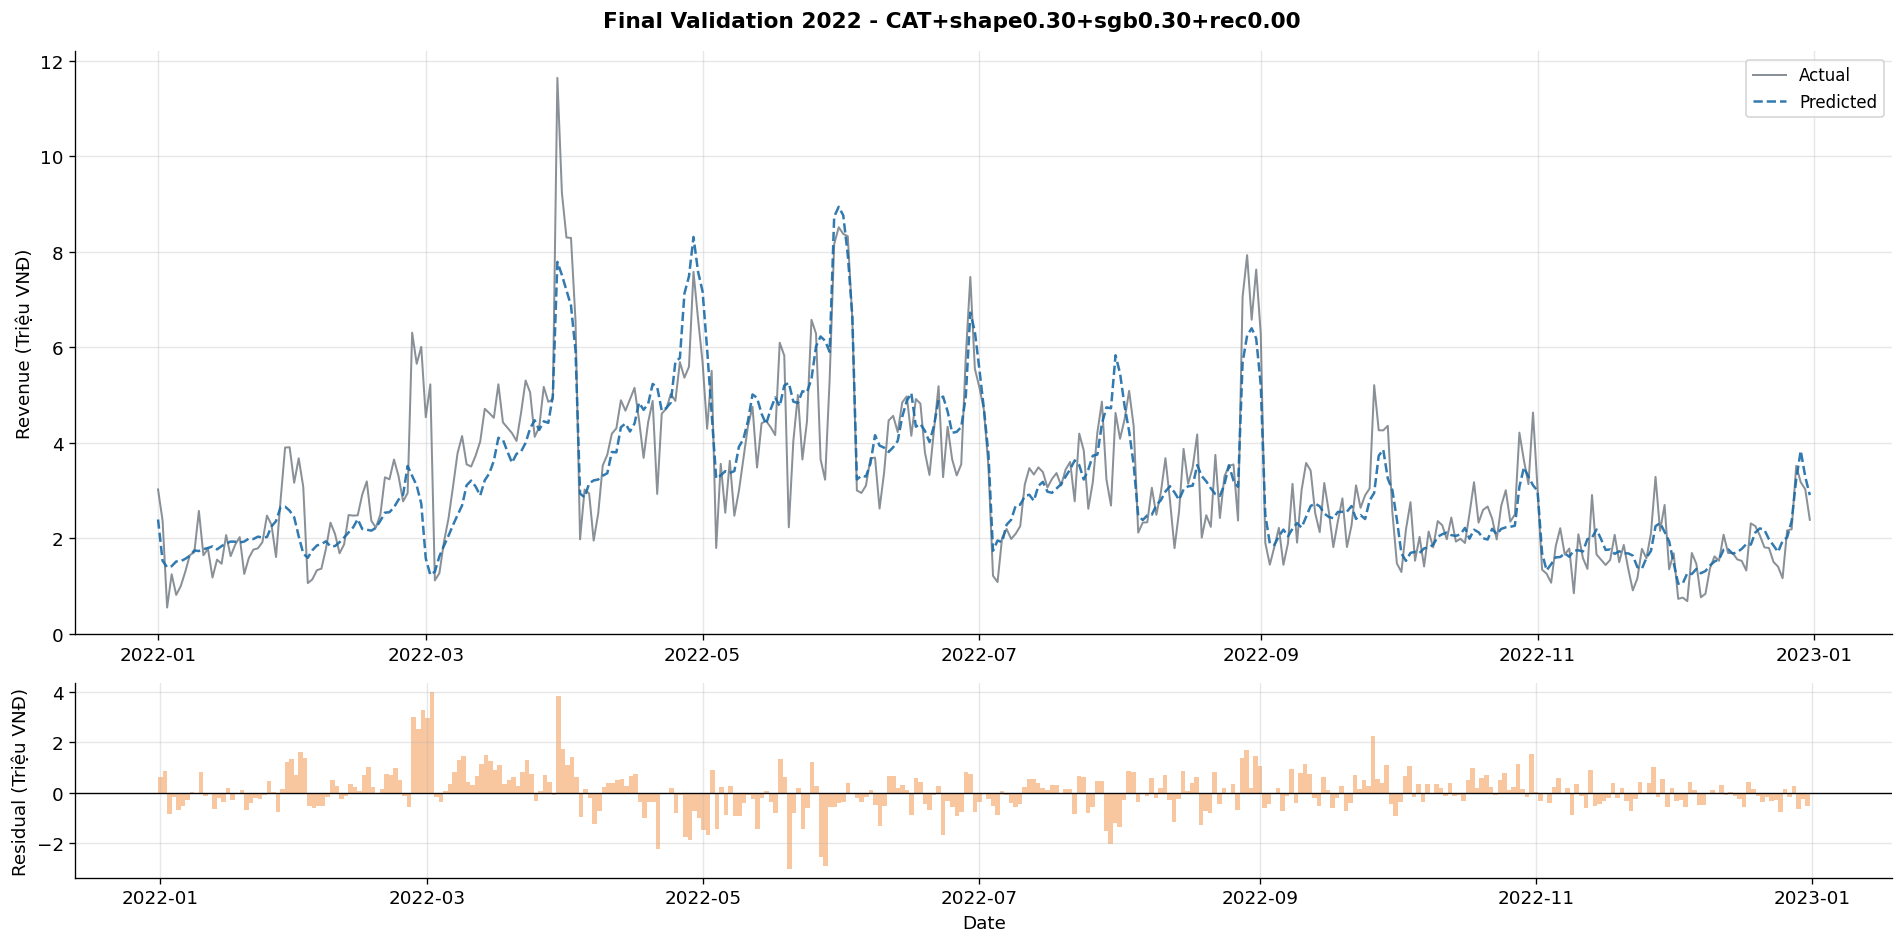


Comparison with baselines and model stages:
  Model                              MAE         RMSE       R2
  ------------------------- ------------ ------------ --------
  Seasonal Naive                 795,286    1,095,124    0.571
  Monthly Median               1,321,645    1,643,697    0.033
  Seasonal Growth                665,230      892,233    0.715
  LGBM                           796,956    1,044,028    0.610
  XGB                            796,949    1,038,512    0.614
  CAT_RAW                        679,000      964,290    0.667
  ENS_FIXED                      688,319      959,896    0.670
  RAW_SELECTED                   679,000      964,290    0.667
  SHAPE_SELECTED                 639,280      904,902    0.707
  FINAL (CAT)                    598,325      838,716    0.748


In [9]:

plot_actual_vs_predicted(
    dates=valid_df["Date"].values,
    y_true=valid_df["Revenue"].values,
    y_pred=selected_val_pred_final,
    title=f"Final Validation 2022 - {FINAL_REVENUE_CANDIDATE_NAME}",
)

print()
print("Comparison with baselines and model stages:")
comparison = [
    ("Seasonal Naive", seasonal_m),
    ("Monthly Median", monthly_m),
    ("Seasonal Growth", sgb_m),
    ("LGBM", best_art["lgbm_metrics"]),
    ("XGB", best_art["xgb_metrics"]),
]
if best_art["cat_metrics"] is not None:
    comparison.append(("CAT_RAW", best_art["cat_metrics"]))
comparison.append(("ENS_FIXED", best_art["ens_metrics"]))
comparison.append(("RAW_SELECTED", raw_selected_metrics))
comparison.append(("SHAPE_SELECTED", shape_selected_metrics))
comparison.append((f"FINAL ({best_model_name})", best_selected_metrics))

print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R2':>8}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*8}")
for name, m in comparison:
    print(f"  {name:<25} {m['MAE']:>12,.0f} {m['RMSE']:>12,.0f} {m['R2']:>8.3f}")


## Section 5b - Prophet Diagnostic Only

Section này chỉ giữ Prophet như một **diagnostic tùy chọn**, không còn là phần của flow chính.

Lý do:
- Prophet không cho thấy lợi thế rõ ràng trong bài toán hiện tại.
- Mục tiêu bây giờ là tối ưu long-horizon framework, không phải thêm một model phụ để pha blend.

Nếu muốn thử lại Prophet, chỉ cần bật `USE_PROPHET_BLEND = True` ở cell code bên dưới.





In [10]:
USE_PROPHET_BLEND = False
PROPHET_BLEND_WEIGHT = 0.10 if USE_PROPHET_BLEND else 0.0

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception as exc:
    Prophet = None
    PROPHET_AVAILABLE = False
    PROPHET_BLEND_WEIGHT = 0.0
    print(f"Prophet unavailable: {type(exc).__name__}: {exc}")
    print("To try Prophet, install it in this environment: pip install prophet")


def _prophet_holidays_until(end_date):
    tet_dates = pd.to_datetime([
        "2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
        "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
        "2022-02-01", "2023-01-22", "2024-02-10",
    ])
    rows = []
    end_date = pd.Timestamp(end_date)
    for dt in tet_dates:
        if dt <= end_date:
            rows.append({"holiday": "tet", "ds": dt, "lower_window": -21, "upper_window": 7})
    for year in range(2012, end_date.year + 1):
        for month, day in [(1, 1), (4, 30), (5, 1), (9, 2), (11, 11), (12, 12)]:
            dt = pd.Timestamp(year=year, month=month, day=day)
            if dt <= end_date:
                rows.append({"holiday": f"event_{month}_{day}", "ds": dt, "lower_window": -3, "upper_window": 2})
    return pd.DataFrame(rows)


def prophet_forecast_revenue(train_data, forecast_dates):
    if not PROPHET_AVAILABLE:
        return None
    train_prophet = train_data[["Date", "Revenue"]].rename(columns={"Date": "ds", "Revenue": "y"}).copy()
    train_prophet["y"] = np.log1p(train_prophet["y"].clip(lower=0))
    forecast_dates = pd.to_datetime(list(forecast_dates))
    holidays = _prophet_holidays_until(max(train_prophet["ds"].max(), forecast_dates.max()))
    model = Prophet(
        holidays=holidays,
        yearly_seasonality=20,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="additive",
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
        holidays_prior_scale=10.0,
    )
    model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    model.fit(train_prophet)
    future = pd.DataFrame({"ds": forecast_dates})
    forecast = model.predict(future)
    return np.maximum(np.expm1(forecast["yhat"].to_numpy(dtype=float)), 0.0)


prophet_valid_pred = None
if USE_PROPHET_BLEND and PROPHET_AVAILABLE:
    print("Fitting Prophet validation diagnostic...")
    prophet_valid_pred = prophet_forecast_revenue(train_df, valid_df["Date"])
    prophet_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), prophet_valid_pred)
    tree_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), selected_val_pred)
    prophet_blend_pred = (
        (1.0 - PROPHET_BLEND_WEIGHT) * selected_val_pred
        + PROPHET_BLEND_WEIGHT * prophet_valid_pred
    )
    prophet_blend_pred = np.maximum(prophet_blend_pred, 0)
    prophet_blend_metrics = compute_metrics(valid_df["Revenue"].to_numpy(dtype=float), prophet_blend_pred)
    display(pd.DataFrame([
        {"candidate": "TREE_SELECTED", **tree_metrics},
        {"candidate": "PROPHET", **prophet_metrics},
        {"candidate": f"TREE_{1-PROPHET_BLEND_WEIGHT:.0%}_PROPHET_{PROPHET_BLEND_WEIGHT:.0%}", **prophet_blend_metrics},
    ]))
    print(f"Prophet diagnostic blend weight: {PROPHET_BLEND_WEIGHT:.2f}")
else:
    print("Prophet diagnostic skipped. Main flow stays tree-based.")



Prophet diagnostic skipped. Main flow stays tree-based.


## Section 5c - Business Shape And COGS Ratio Calibration

Section này dùng dữ liệu transaction/review/return theo cách future-safe.

- `Component shape`: tạo seasonal shape từ `orders_count`, `qty_per_order`, `gross_per_qty`, rồi normalize về cùng mean với base prediction. Cách này chỉ chỉnh hình dạng theo ngày, không kéo toàn bộ level xuống như decomposition cũ.
- `COGS ratio model`: train model riêng cho tỷ lệ `COGS / Revenue`, rồi chọn blend với monthly ratio baseline theo MAE trên holdout 2022.

Các weight được chọn trên validation 2022 và áp dụng lại cho test.



In [11]:

print("Final revenue calibration candidates:")
display(final_validation_df)
print()

print("Component shape validation:")
display(component_shape_df)
print(f"Selected component shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print()

print("Seasonal growth blend validation:")
display(seasonal_blend_df)
print(f"Selected seasonal growth weight: {BEST_SEASONAL_GROWTH_WEIGHT:.2f}")
print()

print("Recovery calibration validation:")
display(recovery_df)
print(f"Selected recovery strength: {BEST_RECOVERY_STRENGTH:.2f}")
print()

print("COGS ratio validation:")
display(cogs_ratio_df)
print(f"Selected COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")


Final revenue calibration candidates:


,candidate,MAE,RMSE,R2
0,Raw CAT,679000.321986,964289.882249,0.667322
1,CAT + component shape,639280.125031,904902.141836,0.707037
2,+ seasonal growth blend (0.30),598324.779601,838715.592604,0.748326
3,+ recovery calibration (0.00),598324.779601,838715.592604,0.748326



Component shape validation:


,component_shape_weight,MAE,RMSE,R2
0,0.30,639280.125031,904902.141836,0.707037
1,0.20,646695.225173,916816.073179,0.699272
2,0.15,652112.614335,925818.868136,0.693337
3,0.10,659594.917637,936778.562740,0.686033
4,0.05,668442.688882,949627.405397,0.677362
5,0.00,679000.321986,964289.882249,0.667322


Selected component shape weight: 0.30

Seasonal growth blend validation:


...

Selected seasonal growth weight: 0.30

Recovery calibration validation:


,recovery_strength,MAE,RMSE,R2
0,0.00,598324.779601,838715.592604,0.748326
1,0.25,598573.007066,838745.906280,0.748307
2,0.50,598862.131852,839083.258739,0.748105
3,0.75,599242.991843,839727.279932,0.747718


Selected recovery strength: 0.00

COGS ratio validation:


,cogs_ratio_model_weight,MAE,RMSE,R2
0,1.00,533300.558317,748980.779219,0.736267
1,0.75,537970.561936,758754.395507,0.729339
2,0.50,543180.011642,770291.064035,0.721046
3,0.25,550608.116132,783512.909616,0.711388
4,0.00,559175.744956,798336.208190,0.700364


Selected COGS ratio model weight: 1.00


## Section 6 - Final Training On Full History

Sau khi chọn candidate bằng validation, section này train lại model trên toàn bộ lịch sử 2012-2022.

Lý do train lại:

- Khi nộp bài, mình được phép dùng toàn bộ dữ liệu lịch sử đã công bố.
- Validation 2022 chỉ dùng để chọn model, không phải để bỏ đi khi train final.

Các cell trong section này build full feature matrix và train final LGBM/XGB/CatBoost.



### 6.1 Build Full Training Matrix

Cell code bên dưới build supervised training frame cho toàn bộ lịch sử.

Nó dùng `best_config_flags` từ validation để quyết định có dùng promo/traffic/inventory hay không.

Output chính:

- `X_full`: feature matrix sau imputation.
- `y_full_log`: target `log1p(Revenue)`.
- `feat_cols_full`: danh sách feature dùng cho final model.
- `feature_medians_full`: giá trị fill dùng cho recursive forecasting.



In [12]:
# Build full supervised frame (train trên toàn bộ 2012-2022)
FULL_PROFILE_CUTOFF = sales["Date"].max()
(
    final_promo_profile,
    final_traffic_profile,
    final_inventory_profile,
    final_business_daily,
    final_business_profile,
    final_business_groups,
) = _profiles_for_flags(best_config_flags, FULL_PROFILE_CUTOFF)
final_component_profile = build_component_shape_profile(
    orders=orders,
    order_items=order_items,
    products=products,
    sales=sales,
    train_cutoff=FULL_PROFILE_CUTOFF,
)

frame_full, feat_cols_full = make_supervised_frame(
    sales,
    final_promo_profile,
    traffic_profile=final_traffic_profile,
    inventory_profile=final_inventory_profile,
    business_daily=final_business_daily,
    business_profile=final_business_profile,
    business_groups=final_business_groups,
)

final_drop_cols = [c for c in best_config_flags.get("drop_cols", []) if c in feat_cols_full]
feat_cols_full = [c for c in feat_cols_full if c not in final_drop_cols]

X_full_raw = frame_full[feat_cols_full].copy()
y_full_log = np.log1p(frame_full["Revenue"].clip(lower=0)).copy()
dates_full = frame_full["Date"].values

X_full, feature_medians_full = impute_feature_frame(X_full_raw, fill_values=best_feature_fill_values)

print(f"Full profile cutoff: {FULL_PROFILE_CUTOFF.date()}")
print(f"Full train: {X_full.shape[0]:,} rows × {X_full.shape[1]} features")
if final_drop_cols:
    print(f"Final pruned columns: {len(final_drop_cols)}")
print(f"Final business groups: {final_business_groups if final_business_groups else 'disabled'}")
print(f"Recursive blend weight: {RECURSIVE_BLEND_WEIGHT:.2f}")
print(f"Component shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print(f"COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")
print(f"Date range: {pd.Series(dates_full).min()} to {pd.Series(dates_full).max()}")
print("Target transform: log1p(Revenue); recursive predictions use expm1 inverse.")




Full profile cutoff: 2022-12-31
Full train: 3,468 rows × 132 features
Final pruned columns: 32
Final business groups: disabled
Recursive blend weight: 0.10
Component shape weight: 0.30
COGS ratio model weight: 1.00
Date range: 2013-07-04 00:00:00 to 2022-12-31 00:00:00
Target transform: log1p(Revenue); recursive predictions use expm1 inverse.


### 6.2 Internal TimeSeries CV For Iteration Count

Cell code bên dưới chạy TimeSeriesSplit để lấy số vòng train hợp lý cho final model.

Lưu ý quan trọng:

- Metric trong cell này đang ở log scale, nên MAE/RMSE có thể nhìn rất nhỏ hoặc bị format thành 0.
- Cell này không dùng để chọn model cuối.
- Model cuối vẫn được chọn bằng original-scale holdout metrics ở Section 4.

Vai trò chính của cell: tránh final model dùng số iteration quá thấp.

#### **Kết quả 5-Fold TimeSeries CV này là gì?**

Cell này dùng để đánh giá nhanh độ ổn định của từng mô hình trên dữ liệu lịch sử theo cách tôn trọng thứ tự thời gian.

Cụ thể, mỗi mô hình (`LightGBM`, `XGBoost`, `CatBoost`) được chạy với `TimeSeriesSplit`, nghĩa là:

- train trên quá khứ
- validate trên một giai đoạn thời gian nằm sau tập train
- lặp lại nhiều fold để xem mô hình có ổn định qua các năm hay không

Khác với `K-Fold` thông thường, `TimeSeriesSplit` không xáo trộn dữ liệu. Điều này rất quan trọng vì bài toán hiện tại là dự báo chuỗi thời gian, nên tuyệt đối không được để mô hình “nhìn thấy tương lai” khi train.

#### Mục đích của cell này

Cell này không dùng để tạo submission trực tiếp.

Vai trò chính của nó là:

- kiểm tra mô hình nào học pattern lịch sử tốt hơn
- so sánh độ ổn định của các mô hình qua nhiều giai đoạn thời gian
- hỗ trợ lựa chọn mô hình hoặc số vòng train hợp lý
- phát hiện dấu hiệu overfitting nếu performance giữa các fold dao động quá mạnh





In [13]:
# TimeSeriesSplit CV (5-fold) - lấy best_iter trên log target cho final training
# Metrics in this table are on log scale; holdout metrics above are the decision metrics on original scale.
tscv = TimeSeriesCV(n_splits=5, test_size=365)

print("Running 5-fold TimeSeriesCV for LightGBM on log target...")
cv_results_lgbm, oof_lgbm, _ = tscv.cross_validate_lgbm(
    X_full.values, y_full_log.values, dates_full
)
print_cv_table(cv_results_lgbm, "LightGBM (log target)")
best_lgbm_iter = max(1500, int(cv_results_lgbm["best_iter"].mean()))

print()
print("Running 5-fold TimeSeriesCV for XGBoost on log target...")
cv_results_xgb, oof_xgb, _ = tscv.cross_validate_xgb(
    X_full.values, y_full_log.values, dates_full
)
print_cv_table(cv_results_xgb, "XGBoost (log target)")
best_xgb_iter = max(1500, int(cv_results_xgb["best_iter"].mean()))

best_cat_iter = None
if CatBoostRegressor is not None:
    print()
    print("Running 5-fold TimeSeriesCV for CatBoost on log target...")
    cv_results_cat, oof_cat, _ = tscv.cross_validate_catboost(
        X_full.values, y_full_log.values, dates_full
    )
    print_cv_table(cv_results_cat, "CatBoost (log target)")
    valid_iters = cv_results_cat["best_iter"].dropna()
    best_cat_iter = max(1500, int(valid_iters.mean())) if len(valid_iters) else CATBOOST_PARAMS["iterations"]
else:
    print()
    print("Skipping CatBoost CV (package not installed)")


Running 5-fold TimeSeriesCV for LightGBM on log target...
[500]	valid_0's l1: 0.17269
  Fold 1 LGBM best_iteration=464
[500]	valid_0's l1: 0.200186
[1000]	valid_0's l1: 0.199833
  Fold 2 LGBM best_iteration=870
  Fold 3 LGBM best_iteration=210
  Fold 4 LGBM best_iteration=114
[500]	valid_0's l1: 0.200254
  Fold 5 LGBM best_iteration=750
────────────────────────────────────────────────────────────────────────────────
  LightGBM (log target) — 5-Fold TimeSeriesSplit CV Results
────────────────────────────────────────────────────────────────────────────────
  Fold     Train Val Period                                 MAE       RMSE       R²
  ───── ──────── ─────────────────────────────────── ────────── ────────── ────────
  1        1,643 2018-01-02 → 2019-01-01                      0          0    0.858
  2        2,008 2019-01-02 → 2020-01-01                      0          0    0.754
  3        2,373 2020-01-02 → 2020-12-31                      0          0    0.779
  4        2,738 20

## Section 6a - Optuna Diagnostic Only

Section này giữ lại Optuna như một **diagnostic tùy chọn**. Mặc định notebook không dùng Optuna trong flow chính.

Lý do:
- Optuna chưa cho thấy cải thiện leaderboard rõ ràng.
- Bài toán hiện tại bị chi phối nhiều hơn bởi long-horizon drift và calibration framework.

Nếu muốn chạy lại Optuna, chỉ cần bật `USE_OPTUNA_CATBOOST = True`.





In [14]:
USE_OPTUNA_CATBOOST = False
OPTUNA_CATBOOST_TRIALS = 24
OPTUNA_CATBOOST_TIMEOUT_SEC = None

catboost_final_params = CATBOOST_PARAMS.copy()
catboost_final_best_iter = None
catboost_tuned_metrics = None
catboost_tuned_val = None

try:
    import optuna
    from optuna.samplers import TPESampler
    OPTUNA_AVAILABLE = True
except Exception as exc:
    optuna = None
    OPTUNA_AVAILABLE = False
    print(f"Optuna unavailable: {type(exc).__name__}: {exc}")
    print("To run CatBoost tuning, install Optuna in this environment: pip install optuna")

if USE_OPTUNA_CATBOOST and OPTUNA_AVAILABLE and CatBoostRegressor is not None:
    print("Running Optuna diagnostic for CatBoost on the current best config...")

    tune_frame, tune_feat_cols = make_supervised_frame(
        train_df,
        best_promo_profile,
        traffic_profile=best_traffic_profile,
        inventory_profile=best_inventory_profile,
        business_daily=best_business_daily,
        business_profile=best_business_profile,
        business_groups=best_business_groups,
    )
    tune_drop_cols = [c for c in best_config_flags.get("drop_cols", []) if c in tune_feat_cols]
    tune_feat_cols = [c for c in tune_feat_cols if c not in tune_drop_cols]

    X_tune_raw = tune_frame[tune_feat_cols].copy()
    y_tune_log = np.log1p(tune_frame["Revenue"].clip(lower=0)).copy()
    X_tune, tune_fill_values = impute_feature_frame(X_tune_raw, fill_values=best_feature_fill_values)

    eval_size = min(365, max(90, len(X_tune) // 5))
    X_fit, X_eval = X_tune.iloc[:-eval_size], X_tune.iloc[-eval_size:]
    y_fit, y_eval = y_tune_log.iloc[:-eval_size], y_tune_log.iloc[-eval_size:]
    seasonal_anchor = seasonal_growth_baseline(train_df, valid_df["Date"], "Revenue")
    y_valid_target = valid_df["Revenue"].to_numpy(dtype=float)

    def optuna_cat_objective(trial):
        params = CATBOOST_PARAMS.copy()
        params.update({
            "iterations": trial.suggest_int("iterations", 2000, 5000, step=500),
            "depth": trial.suggest_int("depth", 6, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3.0, 15.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.5),
            "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
            "subsample": trial.suggest_float("subsample", 0.70, 1.0),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 60, step=5),
        })

        model = CatBoostRegressor(**params)
        model.fit(
            X_fit, y_fit,
            eval_set=(X_eval, y_eval),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=False,
        )

        pred = recursive_forecast(
            model, train_df, valid_df["Date"], tune_feat_cols, best_promo_profile,
            traffic_profile=best_traffic_profile,
            inventory_profile=best_inventory_profile,
            business_daily=best_business_daily,
            business_profile=best_business_profile,
            business_groups=best_business_groups,
            feature_fill_values=tune_fill_values,
            anchor_pred=seasonal_anchor,
            blend_weight=RECURSIVE_BLEND_WEIGHT,
            ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
            predict_log_target=True,
        )
        pred = calibrate_monthly_predictions(pred, valid_df["Date"], train_df, "Revenue")
        metrics = compute_metrics(y_valid_target, pred)

        try:
            best_iter = int(model.get_best_iteration())
        except Exception:
            best_iter = int(params["iterations"])
        trial.set_user_attr("best_iter", best_iter)
        trial.set_user_attr("RMSE", float(metrics["RMSE"]))
        trial.set_user_attr("R2", float(metrics["R2"]))
        return float(metrics["MAE"])

    study = optuna.create_study(
        direction="minimize",
        sampler=TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(
        optuna_cat_objective,
        n_trials=OPTUNA_CATBOOST_TRIALS,
        timeout=OPTUNA_CATBOOST_TIMEOUT_SEC,
        show_progress_bar=False,
    )

    best_trial = study.best_trial
    catboost_final_params = CATBOOST_PARAMS.copy()
    catboost_final_params.update(best_trial.params)
    catboost_final_best_iter = int(best_trial.user_attrs.get("best_iter", best_trial.params["iterations"]))

    tuned_cat_model = CatBoostRegressor(**catboost_final_params)
    tuned_cat_model.fit(
        X_fit, y_fit,
        eval_set=(X_eval, y_eval),
        use_best_model=True,
        early_stopping_rounds=200,
        verbose=False,
    )
    try:
        catboost_final_best_iter = int(tuned_cat_model.get_best_iteration())
    except Exception:
        catboost_final_best_iter = int(catboost_final_params.get("iterations", catboost_final_best_iter))

    catboost_tuned_val = recursive_forecast(
        tuned_cat_model, train_df, valid_df["Date"], tune_feat_cols, best_promo_profile,
        traffic_profile=best_traffic_profile,
        inventory_profile=best_inventory_profile,
        business_daily=best_business_daily,
        business_profile=best_business_profile,
        business_groups=best_business_groups,
        feature_fill_values=tune_fill_values,
        anchor_pred=seasonal_anchor,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    catboost_tuned_val = calibrate_monthly_predictions(catboost_tuned_val, valid_df["Date"], train_df, "Revenue")
    catboost_tuned_metrics = compute_metrics(y_valid_target, catboost_tuned_val)

    base_cat_metrics = best_artifact["cat_metrics"] if best_artifact["cat_metrics"] is not None else {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}
    tuning_summary = pd.DataFrame([
        {"candidate": "CAT_CURRENT", **base_cat_metrics},
        {"candidate": "CAT_TUNED_OPTUNA", **catboost_tuned_metrics},
    ])
    display(tuning_summary)

    print("Optuna best params:")
    print(study.best_params)
    print(f"Optuna best iteration: {catboost_final_best_iter}")

    if np.isfinite(base_cat_metrics["MAE"]) and catboost_tuned_metrics["MAE"] < base_cat_metrics["MAE"]:
        print("Applying tuned CatBoost artifact because validation MAE improved.")
        best_artifact["cat_val"] = catboost_tuned_val
        best_artifact["cat_metrics"] = catboost_tuned_metrics
        best_artifact["cat_model"] = tuned_cat_model
        if catboost_tuned_metrics["MAE"] < best_selected_metrics["MAE"]:
            best_model_name = "CAT"
            best_selected_metrics = catboost_tuned_metrics
    else:
        print("Keeping current CatBoost artifact; Optuna did not improve holdout MAE.")
        catboost_final_params = CATBOOST_PARAMS.copy()
        catboost_final_best_iter = None
else:
    print("Skipping Optuna CatBoost diagnostic in main flow.")




Skipping Optuna CatBoost diagnostic in main flow.


### 6.3 Train Final Models

Cell code bên dưới train final LGBM, XGB và CatBoost trên toàn bộ dữ liệu lịch sử.

Các model này dự đoán log target, nên khi forecast tương lai cần inverse bằng `expm1`. Việc inverse được xử lý trong `recursive_forecast()` khi bật `predict_log_target=True`.



In [15]:
print(f"Training final LightGBM (n_estimators={best_lgbm_iter}, log target)...")
final_lgbm = train_final_lgbm(X_full.values, y_full_log.values, best_iter=best_lgbm_iter)
print("  LightGBM done")

print(f"Training final XGBoost  (n_estimators={best_xgb_iter}, log target)...")
final_xgb = train_final_xgb(X_full.values, y_full_log.values, best_iter=best_xgb_iter)
print("  XGBoost done")

final_cat = None
if CatBoostRegressor is not None:
    final_cat_params = catboost_final_params.copy() if catboost_final_params is not None else CATBOOST_PARAMS.copy()
    cat_iter = catboost_final_best_iter if catboost_final_best_iter is not None else best_cat_iter
    if cat_iter is None:
        cat_iter = final_cat_params.get("iterations", CATBOOST_PARAMS["iterations"])
    final_cat_event_weights = compute_event_sample_weights(
        frame_full["Date"],
        sale_weight=CAT_EVENT_PRE_SALE_WEIGHT,
        sale_day_weight=CAT_EVENT_SALE_DAY_WEIGHT,
        tet_weight=CAT_EVENT_TET_WEIGHT,
        q1_end_weight=CAT_EVENT_Q1_END_WEIGHT,
        aug_end_weight=CAT_EVENT_AUG_END_WEIGHT,
        back2school_weight=CAT_EVENT_BACK2SCHOOL_WEIGHT,
    )
    final_cat_recency_weights = compute_recency_sample_weights(frame_full["Date"])
    final_cat_sample_weights = combine_sample_weights(final_cat_event_weights, final_cat_recency_weights)
    print(f"Training final CatBoost (iterations={cat_iter}, log target)...")
    print(f"  Final CAT event weight mean   : {final_cat_event_weights.mean():.3f} (max={final_cat_event_weights.max():.1f})")
    print(f"  Final CAT recency weight mean : {final_cat_recency_weights.mean():.3f} (max={final_cat_recency_weights.max():.1f})")
    print(f"  Final CAT combined weight mean: {final_cat_sample_weights.mean():.3f} (max={final_cat_sample_weights.max():.1f})")
    final_cat = train_final_catboost(
        X_full.values,
        y_full_log.values,
        best_iter=cat_iter,
        params=final_cat_params,
        sample_weight=final_cat_sample_weights,
    )
    print("  CatBoost done")
    print(
        f"  Final CAT params: depth={final_cat_params.get('depth')} "
        f"lr={final_cat_params.get('learning_rate')} "
        f"l2={final_cat_params.get('l2_leaf_reg')} "
        f"bag_temp={final_cat_params.get('bagging_temperature')}"
    )
else:
    print("Skipping final CatBoost training (package not installed)")



Training final LightGBM (n_estimators=1500, log target)...
  LightGBM done
Training final XGBoost  (n_estimators=1500, log target)...
  XGBoost done
Training final CatBoost (iterations=1605, log target)...
  Final CAT event weight mean   : 1.187 (max=2.5)
  Final CAT recency weight mean : 0.829 (max=1.2)
  Final CAT combined weight mean: 1.000 (max=3.2)
  CatBoost done
  Final CAT params: depth=8 lr=0.02 l2=3.0 bag_temp=None


## Section 7 - Forecast Test Revenue

Section này forecast Revenue cho toàn bộ test horizon 548 ngày.

Điểm khó của bài này là horizon dài. Nếu chỉ recursive thuần, lỗi ở ngày đầu có thể lan sang các ngày sau. Vì vậy forecast trong notebook dùng thêm:

- `seasonal_growth_baseline` làm anchor.
- `RECURSIVE_BLEND_WEIGHT` để kéo prediction về baseline mùa vụ.
- `RECURSIVE_EWM_ALPHA` để smoothing prediction.
- Monthly calibration để tránh monthly mean lệch quá xa lịch sử.



### 7.1 Recursive Revenue Forecast For Test Dates

Cell code bên dưới tạo prediction từ từng model cho các ngày trong `sample_submission.csv`.

Các bước chính:

1. Tạo seasonal anchor cho toàn bộ test dates.
2. Chạy recursive forecast cho LGBM.
3. Chạy recursive forecast cho XGB.
4. Chạy recursive forecast cho CatBoost nếu có.
5. Tạo fixed ensemble để diagnostic.
6. Chọn `selected_test_pred` theo `best_model_name`, ví dụ CAT nếu CatBoost là candidate tốt nhất.

`selected_test_pred` là Revenue prediction dùng cho file submission chính.



In [16]:

test_dates = sample_sub["Date"].values
print(f"Predicting {len(test_dates)} test days recursively...")
print(f"  Test: {pd.Timestamp(test_dates[0]).date()} to {pd.Timestamp(test_dates[-1]).date()}")

baseline_test_pred = seasonal_growth_baseline(sales, test_dates, "Revenue")

print("  Running LightGBM recursive...")
lgbm_test_pred = recursive_forecast(
    final_lgbm,
    sales,
    test_dates,
    feat_cols_full,
    final_promo_profile,
    traffic_profile=final_traffic_profile,
    inventory_profile=final_inventory_profile,
    business_daily=final_business_daily,
    business_profile=final_business_profile,
    business_groups=final_business_groups,
    feature_fill_values=feature_medians_full,
    anchor_pred=baseline_test_pred,
    blend_weight=RECURSIVE_BLEND_WEIGHT,
    ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
    predict_log_target=True,
)
lgbm_test_pred = calibrate_monthly_predictions(lgbm_test_pred, sample_sub["Date"], sales, "Revenue")
lgbm_test_pred = calibrate_event_spikes(lgbm_test_pred, sample_sub["Date"], sales, strength=EVENT_SPIKE_CALIBRATION_STRENGTHS)
print("  LightGBM done")

print("  Running XGBoost recursive...")
xgb_test_pred = recursive_forecast(
    final_xgb,
    sales,
    test_dates,
    feat_cols_full,
    final_promo_profile,
    traffic_profile=final_traffic_profile,
    inventory_profile=final_inventory_profile,
    business_daily=final_business_daily,
    business_profile=final_business_profile,
    business_groups=final_business_groups,
    feature_fill_values=feature_medians_full,
    anchor_pred=baseline_test_pred,
    blend_weight=RECURSIVE_BLEND_WEIGHT,
    ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
    predict_log_target=True,
)
xgb_test_pred = calibrate_monthly_predictions(xgb_test_pred, sample_sub["Date"], sales, "Revenue")
xgb_test_pred = calibrate_event_spikes(xgb_test_pred, sample_sub["Date"], sales, strength=EVENT_SPIKE_CALIBRATION_STRENGTHS)
print("  XGBoost done")

cat_test_pred = None
if final_cat is not None:
    print("  Running CatBoost recursive...")
    cat_test_pred = recursive_forecast(
        final_cat,
        sales,
        test_dates,
        feat_cols_full,
        final_promo_profile,
        traffic_profile=final_traffic_profile,
        inventory_profile=final_inventory_profile,
        business_daily=final_business_daily,
        business_profile=final_business_profile,
        business_groups=final_business_groups,
        feature_fill_values=feature_medians_full,
        anchor_pred=baseline_test_pred,
        blend_weight=RECURSIVE_BLEND_WEIGHT,
        ewm_alpha=RECURSIVE_SMOOTH_ALPHA,
        predict_log_target=True,
    )
    cat_test_pred = calibrate_monthly_predictions(cat_test_pred, sample_sub["Date"], sales, "Revenue")
    cat_test_pred = calibrate_event_spikes(cat_test_pred, sample_sub["Date"], sales, strength=EVENT_SPIKE_CALIBRATION_STRENGTHS)
    print("  CatBoost done")

ensemble_test_pred = best_w_lgbm * lgbm_test_pred + best_w_xgb * xgb_test_pred
if cat_test_pred is not None:
    ensemble_test_pred += best_w_catboost * cat_test_pred
ensemble_test_pred = np.maximum(ensemble_test_pred, 0)

if best_model_name == "LGBM":
    selected_test_pred_raw = lgbm_test_pred.copy()
elif best_model_name == "XGB":
    selected_test_pred_raw = xgb_test_pred.copy()
elif best_model_name == "CAT" and cat_test_pred is not None:
    selected_test_pred_raw = cat_test_pred.copy()
else:
    selected_test_pred_raw = ensemble_test_pred.copy()
selected_test_pred_raw = np.maximum(selected_test_pred_raw, 0)

component_shape_test = forecast_component_shape(final_component_profile, sample_sub["Date"])
selected_test_pred_shape = blend_with_normalized_shape(
    selected_test_pred_raw,
    component_shape_test["Revenue"].to_numpy(dtype=float),
    COMPONENT_SHAPE_WEIGHT,
)
selected_test_pred_shape = np.maximum(selected_test_pred_shape, 0)

selected_test_pred = (
    (1.0 - BEST_SEASONAL_GROWTH_WEIGHT) * selected_test_pred_shape
    + BEST_SEASONAL_GROWTH_WEIGHT * baseline_test_pred
)
selected_test_pred = np.maximum(selected_test_pred, 0)
selected_test_pred = apply_recovery_trend_calibration(
    selected_test_pred,
    sample_sub["Date"],
    sales,
    BEST_RECOVERY_STRENGTH,
)
selected_test_pred = np.maximum(selected_test_pred, 0)

print()
print("Test predictions summary:")
summary_rows = [("LGBM", lgbm_test_pred), ("XGB", xgb_test_pred)]
if cat_test_pred is not None:
    summary_rows.append(("CAT", cat_test_pred))
summary_rows.append(("ENS_FIXED", ensemble_test_pred))
summary_rows.append((f"SELECTED_RAW ({best_model_name})", selected_test_pred_raw))
summary_rows.append(("SELECTED_SHAPE", selected_test_pred_shape))
summary_rows.append(("SELECTED_FINAL", selected_test_pred))
for name, pred in summary_rows:
    print(f"  {name:<24}  mean={pred.mean():,.0f}  min={pred.min():,.0f}  max={pred.max():,.0f}  zeros={(pred == 0).sum()}")


Predicting 548 test days recursively...
  Test: 2023-01-01 to 2024-07-01
  Running LightGBM recursive...
  LightGBM done
  Running XGBoost recursive...
  XGBoost done
  Running CatBoost recursive...
  CatBoost done

Test predictions summary:
  LGBM                      mean=4,245,589  min=1,173,645  max=11,329,650  zeros=0
  XGB                       mean=4,234,606  min=1,181,878  max=11,733,845  zeros=0
  CAT                       mean=4,474,811  min=1,229,369  max=12,048,453  zeros=0
  ENS_FIXED                 mean=4,392,387  min=1,225,075  max=11,877,711  zeros=0
  SELECTED_RAW (CAT)        mean=4,474,811  min=1,229,369  max=12,048,453  zeros=0
  SELECTED_SHAPE            mean=4,474,811  min=1,201,238  max=12,993,380  zeros=0
  SELECTED_FINAL            mean=4,101,962  min=1,156,647  max=11,692,843  zeros=0


## Section 8 - Predict COGS From Revenue Ratio

Section này dự báo COGS từ Revenue bằng tỷ lệ lịch sử giữa `COGS` và `Revenue`.

Lý do giữ cách này trong notebook chính:

- COGS tương quan rất mạnh với Revenue.
- Cách này ổn định và ít tạo giá trị bất thường.
- Notebook chính ưu tiên tạo file nộp sạch, không đưa thêm nhánh COGS experimental.



### 8.1 COGS For Selected Candidate

Cell code bên dưới tạo COGS cho candidate cuối được chọn ở Section 4.

Notebook dùng monthly ratio baseline và COGS ratio model, sau đó clamp `COGS <= Revenue * 0.995` để giữ logic biên lợi nhuận hợp lệ.



In [17]:
cogs_monthly = predict_cogs(selected_test_pred, sample_sub["Date"], sales)
cogs_ratio_model, cogs_ratio_pred = forecast_cogs_ratio_model(
    sales,
    selected_test_pred,
    sample_sub["Date"],
    final_promo_profile,
    traffic_profile=final_traffic_profile,
    inventory_profile=final_inventory_profile,
    business_daily=final_business_daily,
    business_profile=final_business_profile,
    business_groups=final_business_groups,
)
cogs_ensemble = (1.0 - COGS_RATIO_MODEL_WEIGHT) * cogs_monthly + COGS_RATIO_MODEL_WEIGHT * cogs_ratio_model
cogs_ensemble = np.minimum(np.maximum(cogs_ensemble, 0), np.maximum(selected_test_pred, 0) * 0.995)
cogs_selected = cogs_ensemble.copy()

print(f"COGS prediction for selected candidate ({best_model_name}):")
print(f"  monthly ratio mean={cogs_monthly.mean():,.0f}")
print(f"  ratio model mean ={cogs_ratio_model.mean():,.0f}")
print(f"  final COGS mean ={cogs_ensemble.mean():,.0f}  min={cogs_ensemble.min():,.0f}  max={cogs_ensemble.max():,.0f}")
print(f"  ratio model blend weight={COGS_RATIO_MODEL_WEIGHT:.2f}")



COGS prediction for selected candidate (CAT):
  monthly ratio mean=3,415,816
  ratio model mean =3,508,196
  final COGS mean =3,508,196  min=975,572  max=10,013,123
  ratio model blend weight=1.00


## Section 9 - Export Final Submission

Section này ghi file nộp cuối cùng.

Output chính:

- `../outputs/submission.csv`

Output phụ để audit:

- `../outputs/submission_final_primary.csv`
- `../outputs/submission_ensemble.csv`

`submission.csv` và `submission_final_primary.csv` là file chính/audit của selected candidate. `submission_ensemble.csv` là diagnostic alias cho fixed ensemble, không phải file chính nếu `best_model_name` không phải `ENS`.



### 9.1 Write Final Files

Cell này build submission từ selected candidate, chạy sanity checks, rồi ghi ra đúng file cần nộp.



In [18]:
os.makedirs("../outputs", exist_ok=True)

sub_ensemble = build_submission(
    sample_sub=sample_sub,
    revenue_pred=ensemble_test_pred,
    cogs_pred=np.minimum(np.maximum(predict_cogs(ensemble_test_pred, sample_sub["Date"], sales), 0), np.maximum(ensemble_test_pred, 0) * 0.995),
    output_path="../outputs/submission_ensemble.csv",
)
run_submission_checks(sub_ensemble, sample_sub)

final_primary = build_submission(
    sample_sub=sample_sub,
    revenue_pred=selected_test_pred,
    cogs_pred=cogs_selected,
    output_path="../outputs/submission.csv",
)
final_primary.to_csv("../outputs/submission_final_primary.csv", index=False)

print()
print(f"Primary submission: ../outputs/submission.csv ({best_model_name} / {best_config_name})")
print(f"Recursive blend weight: {RECURSIVE_BLEND_WEIGHT:.2f}")
print(f"Prophet blend weight: {PROPHET_BLEND_WEIGHT:.2f} (diagnostic only)")
print(f"Component shape weight: {COMPONENT_SHAPE_WEIGHT:.2f}")
print(f"COGS ratio model weight: {COGS_RATIO_MODEL_WEIGHT:.2f}")
print("Saved audit alias: ../outputs/submission_final_primary.csv")
print("Saved diagnostic alias: ../outputs/submission_ensemble.csv")
print("Revenue:", f"mean={final_primary['Revenue'].mean():,.0f}", f"min={final_primary['Revenue'].min():,.0f}", f"max={final_primary['Revenue'].max():,.0f}")
print("COGS   :", f"mean={final_primary['COGS'].mean():,.0f}", f"min={final_primary['COGS'].min():,.0f}", f"max={final_primary['COGS'].max():,.0f}")




Saved 548 rows to ../outputs/submission_ensemble.csv
  SUBMISSION SANITY CHECKS
Columns: Date, Revenue, COGS present
Row count: 548 (matches sample_submission)
Date order matches sample_submission exactly
No negative Revenue values
No negative COGS values
No NaN values
COGS <= Revenue for all days
Revenue range reasonable (mean=4,392,387)

All checks PASSED - Ready to submit!
Saved 548 rows to ../outputs/submission.csv

Primary submission: ../outputs/submission.csv (CAT / D_full_pruned_v1)
Recursive blend weight: 0.10
Prophet blend weight: 0.00 (diagnostic only)
Component shape weight: 0.30
COGS ratio model weight: 1.00
Saved audit alias: ../outputs/submission_final_primary.csv
Saved diagnostic alias: ../outputs/submission_ensemble.csv
Revenue: mean=4,101,962 min=1,156,647 max=11,692,843
COGS   : mean=3,508,196 min=975,572 max=10,013,123


## Section 10 - Explainability

Section này dùng để hiểu model, không ảnh hưởng đến submission.

Mục tiêu:

- Xem feature nào quan trọng nhất.
- Kiểm tra model có dựa vào tín hiệu hợp lý như lag, rolling, mùa vụ, Tết, sale day hay không.
- Phát hiện dấu hiệu model dựa quá nhiều vào feature nhiễu.



### 10.1 LightGBM Feature Importance

Cell code bên dưới plot feature importance từ final LightGBM.

Ý nghĩa:

- Feature importance cao nghĩa là model thường dùng feature đó để split tree.
- Nếu top features là lag/rolling/calendar thì hợp lý.
- Nếu top features toàn external profile yếu hoặc feature lạ, cần kiểm tra lại leakage hoặc noise.



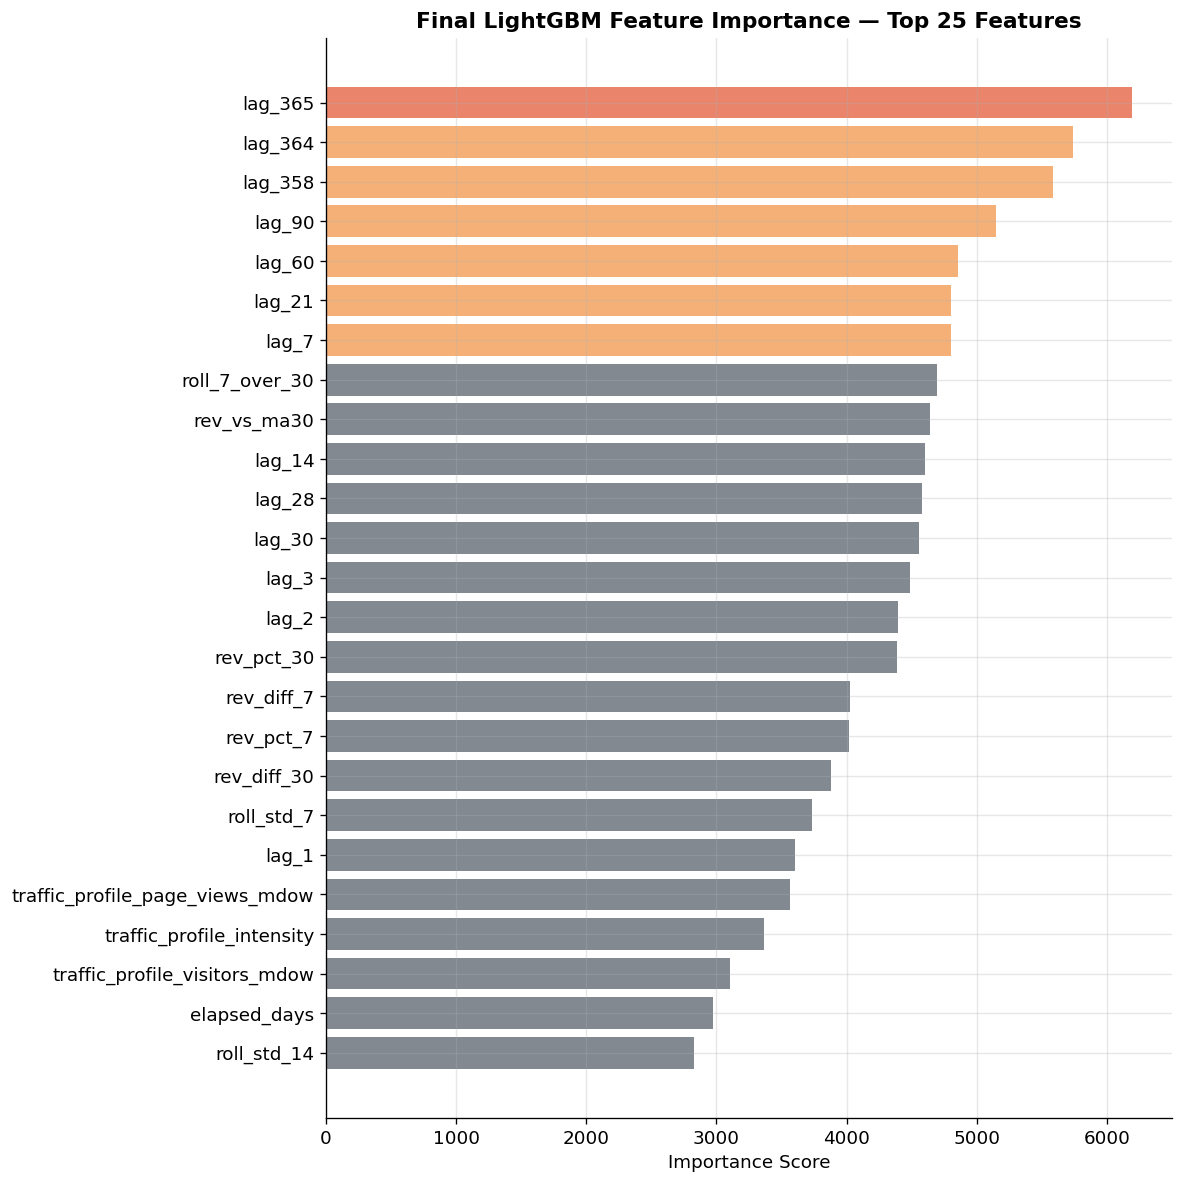

In [19]:
fi_lgbm = pd.Series(final_lgbm.feature_importances_, index=feat_cols_full)
plot_feature_importance(fi_lgbm, "Final LightGBM Feature Importance", top_n=25)

### Business Interpretation

Phần này diễn giải kết quả explainability theo ngôn ngữ business.

Các nhóm tín hiệu thường quan trọng:

- Lag và rolling Revenue: doanh thu có tự tương quan mạnh.
- Calendar và mùa vụ: weekday, month, Tết, sale days.
- Promo/traffic/inventory profile: tín hiệu business phụ trợ, nhưng chỉ hữu ích nếu validation chứng minh có cải thiện.

Không nên kết luận feature tốt chỉ vì nghe hợp lý. Feature phải cải thiện validation sạch.



## Section 11 - Model Card

Model card là bản tóm tắt ngắn của pipeline cuối.

Nó ghi lại:

- Strategy được chọn.
- Số lượng feature.
- Validation MAE/RMSE/R2.
- Số dòng submission.

File nộp chính của notebook này là `../outputs/submission.csv`.



In [20]:

if best_model_name == "ENS":
    strategy_summary = f"ENS_FIXED: LGBM({best_w_lgbm:.0%}) + XGB({best_w_xgb:.0%})"
    if has_catboost_best and best_w_catboost > 0:
        strategy_summary += f" + CAT({best_w_catboost:.0%})"
else:
    strategy_summary = f"{best_model_name} / {best_config_name}"
if COMPONENT_SHAPE_WEIGHT > 0:
    strategy_summary += f" + Shape({COMPONENT_SHAPE_WEIGHT:.0%})"
if BEST_SEASONAL_GROWTH_WEIGHT > 0:
    strategy_summary += f" + SeasonalGrowth({BEST_SEASONAL_GROWTH_WEIGHT:.0%})"
if BEST_RECOVERY_STRENGTH > 0:
    strategy_summary += f" + Recovery({BEST_RECOVERY_STRENGTH:.0%})"
if PROPHET_BLEND_WEIGHT > 0:
    strategy_summary += f" + Prophet({PROPHET_BLEND_WEIGHT:.0%})"
if USE_OPTUNA_CATBOOST and catboost_final_best_iter is not None and best_model_name == "CAT":
    strategy_summary += " + OptunaTunedCAT"

print_model_card(
    ensemble_summary=strategy_summary,
    n_features=len(feat_cols_full),
    cv_mae=best_selected_metrics["MAE"],
    cv_rmse=best_selected_metrics["RMSE"],
    cv_r2=best_selected_metrics["R2"],
    n_rows=len(sample_sub),
)
print("Primary submission: ../outputs/submission.csv")



╔══════════════════════════════════════════════════════════╗
║           GRIDBREAKERS — MODEL SUMMARY CARD             ║
╠══════════════════════════════════════════════════════════╣
║  Strategy    : CAT / D_full_pruned_v1 + Shape(30%) + SeasonalGrowth(30%)║
║  Features    : 132 engineered features                  ║
║  CV Strategy : 5-Fold TimeSeriesSplit (no random split)  ║
║  CV MAE      :      598,325 VNĐ                       ║
║  CV RMSE     :      838,716 VNĐ                       ║
║  CV R²       :        0.748                           ║
║  Random seed : 42 (all models)                           ║
║  Submission  : 548 rows (01/01/2023 → 01/07/2024)     ║
╚══════════════════════════════════════════════════════════╝
Primary submission: ../outputs/submission.csv


## Final Summary

Tóm tắt pipeline chính:

- Validation chọn candidate cuối trên holdout 2022 bằng original-scale MAE.
- Model train trên log target.
- Forecast dùng recursive prediction với seasonal anchor, component shape, COGS ratio model và event-spike calibration.
- `Prophet` và `Optuna` chỉ còn là diagnostic tùy chọn, không nằm trong flow chính.
- File nộp cuối là `../outputs/submission.csv`; file `submission_ensemble.csv` chỉ dùng để so sánh diagnostic nếu final không phải ensemble.

Các hướng experimental như decomposition, robust rolling CV hoặc manual tilt nên để ở notebook riêng nếu cần phân tích thêm.




## Section 12 - Validation & Spike Diagnostics

Section này trực quan hóa lỗi của candidate được chọn trên validation 2022 và kiểm tra các spike window lịch sử.

Mục tiêu không phải tạo thêm submission, mà là tìm nguyên nhân model còn sai:

- Model có miss spike, drift hoặc over-smooth không.
- Lỗi tập trung theo tháng, thứ trong tuần hay event window nào.
- Prediction có bị kéo về trung bình không.
- Các ngày lỗi lớn nhất rơi vào event/Tết/stockout hay ngày thường.
- COGS ratio model có ổn theo tháng không.
- CatBoost đang dùng nhóm feature nào nhiều nhất.
- Q1-end, Aug-end, month-end và quarter-end có phải pattern lặp lại qua nhiều năm không.

Nếu section này chỉ ra lỗi tập trung ở event window, ưu tiên chỉnh `EVENT_SPIKE_CALIBRATION_STRENGTHS` hoặc event sample weight. Nếu lỗi theo tháng, xem lại monthly calibration hoặc component shape. Không dùng section này để ghi đè submission.



Validation diagnostics metrics:
  MAE=598,325  RMSE=838,716  R2=0.748
  Mean residual=50,887  Median residual=-9,761


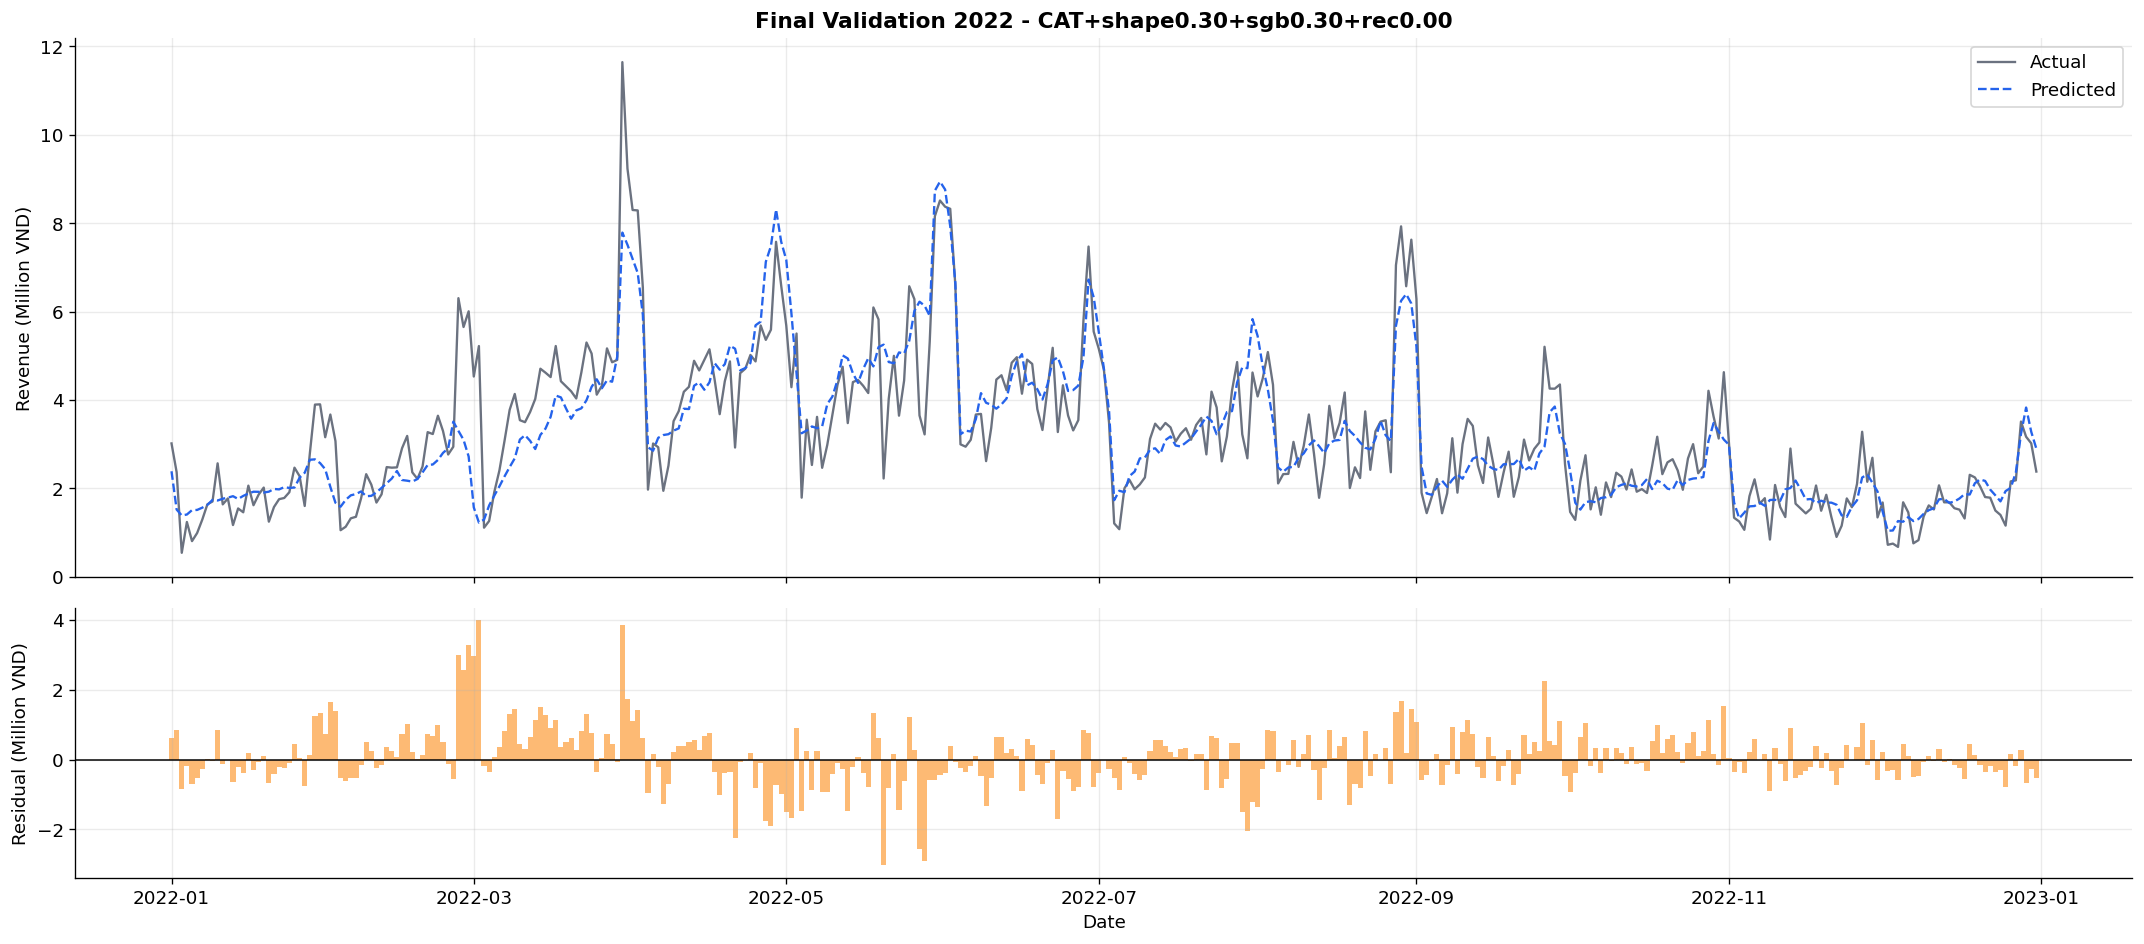

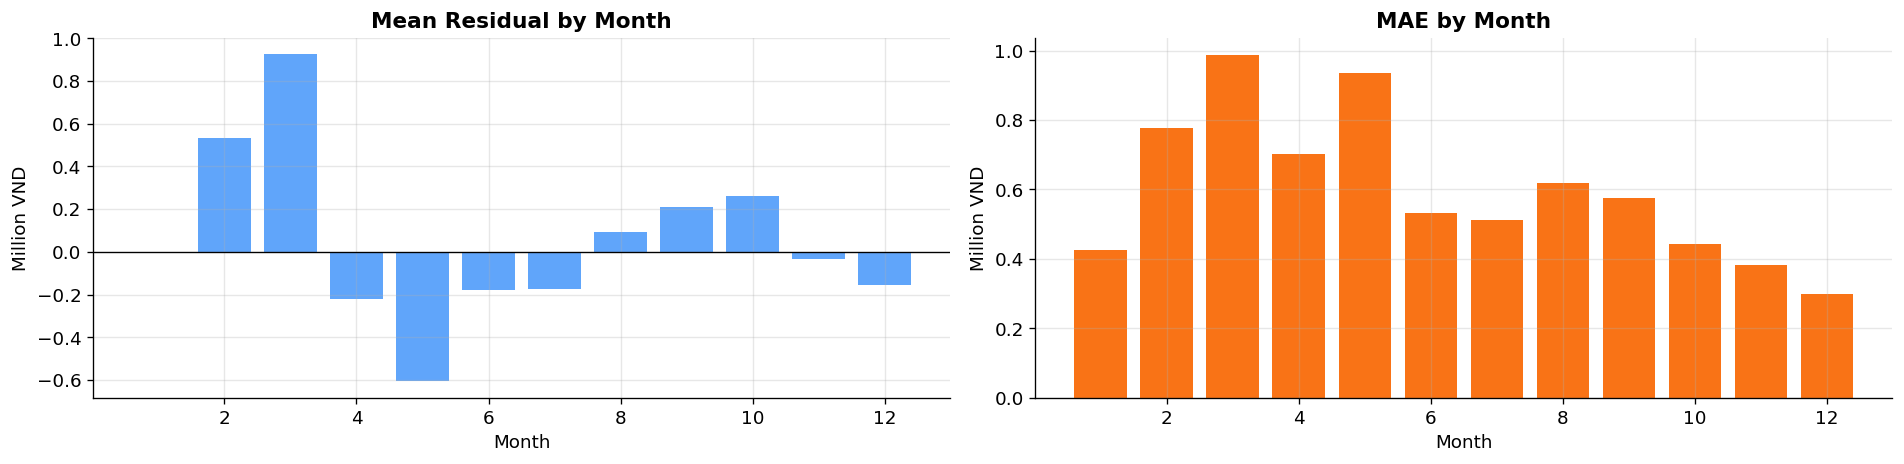

,month,Mean_Residual,MAE,RMSE,Actual_Mean,Pred_Mean,Days
2,3,926304.836297,987990.701350,1.388643e+06,4.436708e+06,3.510403e+06,31
4,5,-606387.612530,935385.899893,1.214427e+06,4.484771e+06,5.091158e+06,31
1,2,532111.984991,775952.797517,1.148573e+06,2.825111e+06,2.292999e+06,28
3,4,-220542.021743,702855.091395,8.954065e+05,4.710184e+06,4.930726e+06,30
7,8,94343.703862,617134.079875,7.690159e+05,3.662676e+06,3.568332e+06,31
8,9,208734.806708,576507.303370,7.197941e+05,2.858810e+06,2.650075e+06,30
5,6,-180973.453434,532170.044329,6.436428e+05,4.537603e+06,4.718577e+06,30
6,7,-173788.830335,510746.886661,6.704531e+05,3.190598e+06,3.364387e+06,31
9,10,259609.980478,443872.551668,5.719489e+05,2.425627e+06,2.166018e+06,31
0,1,-5247.535325,426881.924547,5.542213e+05,1.927671e+06,1.932919e+06,31


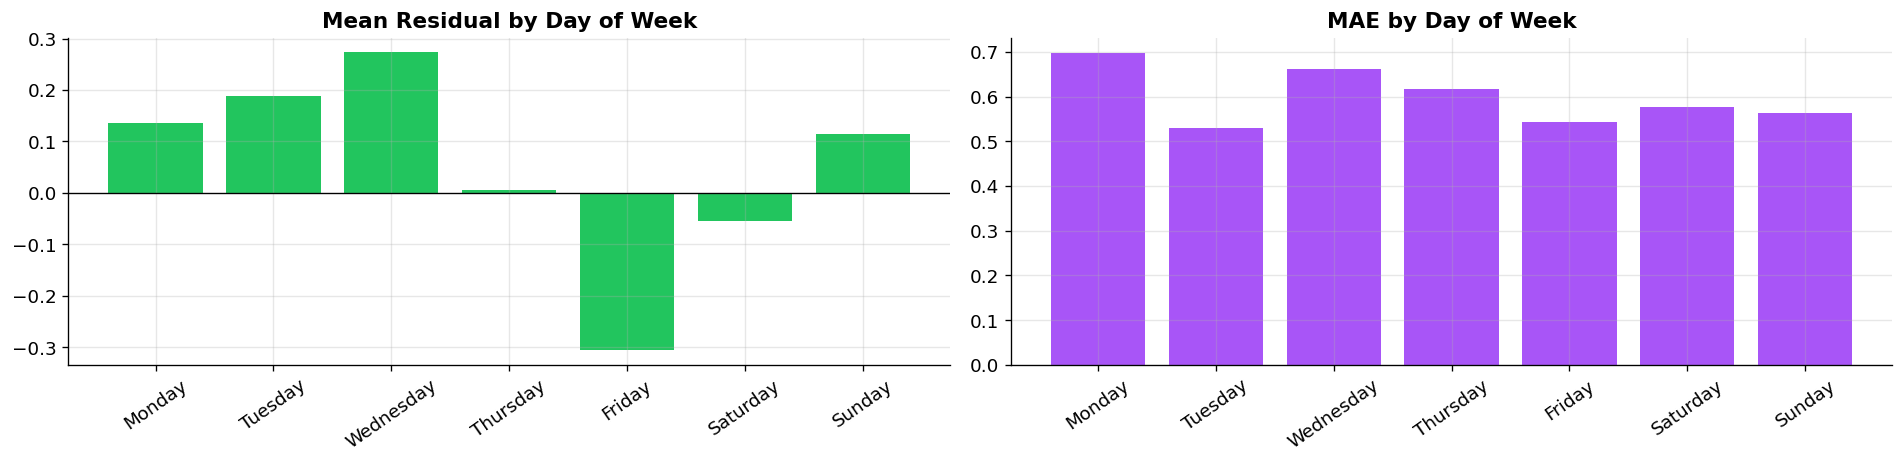

,weekday_name,Mean_Residual,MAE,Days
0,Monday,136679.250635,697353.613384,52
2,Wednesday,273066.257959,662937.278172,52
3,Thursday,5237.276902,616137.149636,52
5,Saturday,-54523.625410,576183.274975,53
6,Sunday,114522.134585,562734.338656,52
4,Friday,-305260.044382,543917.547349,52
1,Tuesday,188516.331855,529436.053199,52


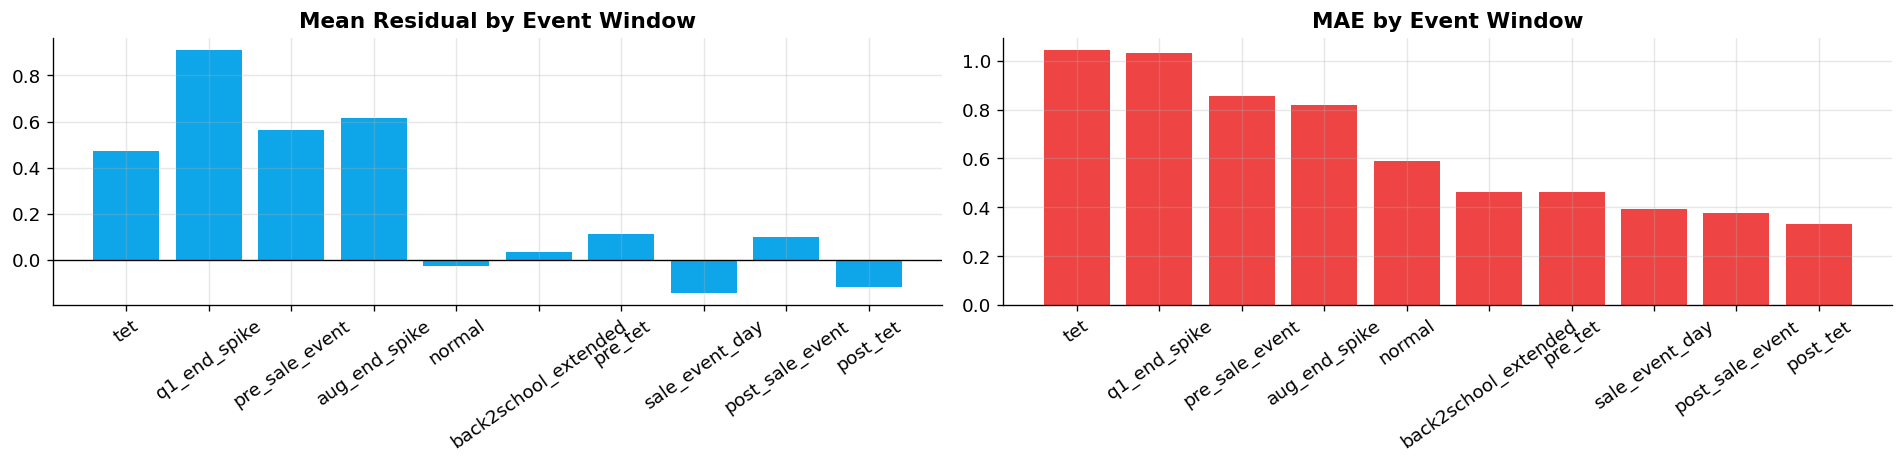

,event_bucket,Mean_Residual,MAE,RMSE,Actual_Mean,Pred_Mean,Days
9,tet,472839.617399,1.042769e+06,1.148429e+06,2.234269e+06,1.761430e+06,4
7,q1_end_spike,910947.330379,1.031194e+06,1.633263e+06,6.322397e+06,5.411450e+06,7
5,pre_sale_event,564877.367686,8.577300e+05,1.411807e+06,3.518326e+06,2.953449e+06,21
0,aug_end_spike,614150.187313,8.197853e+05,1.031677e+06,5.515226e+06,4.901076e+06,7
2,normal,-25696.397910,5.880928e+05,7.812137e+05,3.217842e+06,3.243538e+06,279
1,back2school_extended,34317.080776,4.646533e+05,5.885290e+05,2.732013e+06,2.697696e+06,5
6,pre_tet,111585.685986,4.639829e+05,6.195593e+05,2.305701e+06,2.194115e+06,14
8,sale_event_day,-142197.472293,3.940782e+05,4.770513e+05,2.114688e+06,2.256885e+06,7
3,post_sale_event,99212.698830,3.767168e+05,5.059300e+05,2.582686e+06,2.483473e+06,14
4,post_tet,-116245.805302,3.312538e+05,3.676798e+05,1.775093e+06,1.891339e+06,7


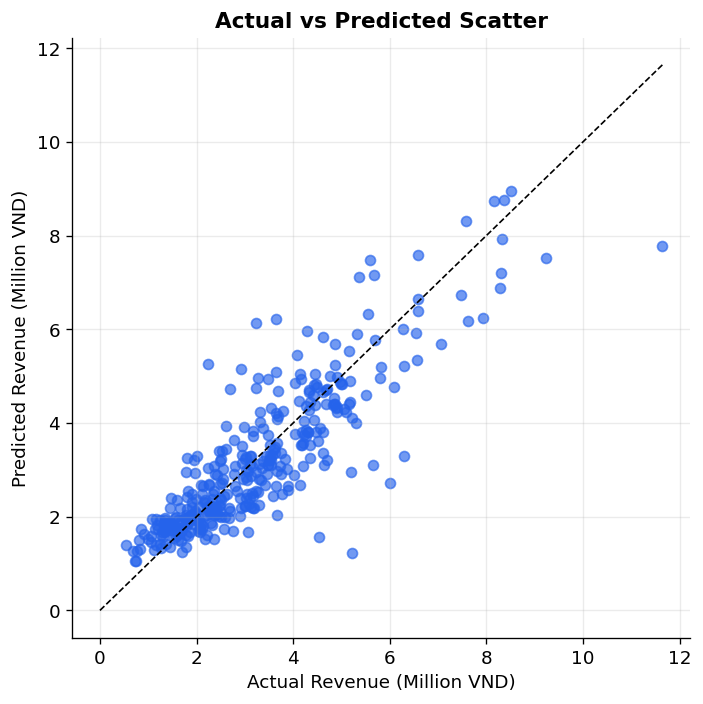

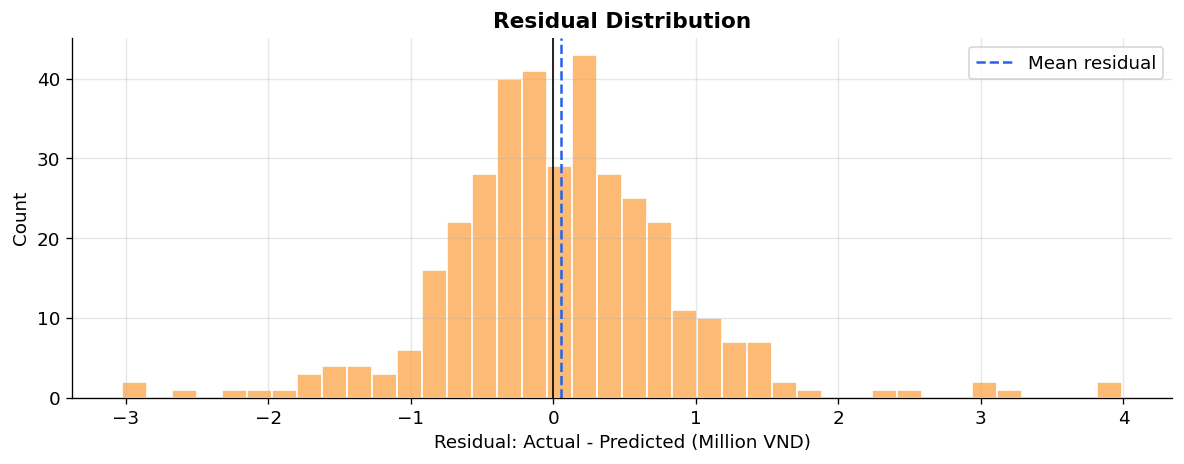

,Date,Actual,Predicted,Residual,AbsError,month,weekday_name,event_bucket,is_pre_tet,is_tet,...,is_1111,is_1212,is_black_friday,is_back2school,is_back2school_extended,is_month_end_window,is_quarter_end_window,is_q1_end_spike,is_aug_end_spike,is_year_end
60,2022-03-02,5221766.09,1.229107e+06,3.992659e+06,3.992659e+06,3,Wednesday,pre_sale_event,0,0,...,0,0,0,0,0,0,0,0,0,0
88,2022-03-30,11643208.73,7.787538e+06,3.855671e+06,3.855671e+06,3,Wednesday,q1_end_spike,0,0,...,0,0,0,0,0,1,1,1,0,0
58,2022-02-28,6007208.86,2.723077e+06,3.284132e+06,3.284132e+06,2,Monday,pre_sale_event,0,0,...,0,0,0,0,0,1,0,0,0,0
139,2022-05-20,2226534.20,5.254048e+06,-3.027514e+06,3.027514e+06,5,Friday,normal,0,0,...,0,0,0,0,0,0,0,0,0,0
56,2022-02-26,6304749.98,3.303465e+06,3.001285e+06,3.001285e+06,2,Saturday,normal,0,0,...,0,0,0,0,0,1,0,0,0,0
59,2022-03-01,4532724.33,1.572673e+06,2.960051e+06,2.960051e+06,3,Tuesday,pre_sale_event,0,0,...,0,0,0,0,0,0,0,0,0,0
147,2022-05-28,3223975.84,6.133457e+06,-2.909482e+06,2.909482e+06,5,Saturday,normal,0,0,...,0,0,0,0,0,1,0,0,0,0
146,2022-05-27,3652675.90,6.225019e+06,-2.572343e+06,2.572343e+06,5,Friday,normal,0,0,...,0,0,0,0,0,1,0,0,0,0
57,2022-02-27,5652340.75,3.101142e+06,2.551199e+06,2.551199e+06,2,Sunday,normal,0,0,...,0,0,0,0,0,1,0,0,0,0
268,2022-09-26,5205389.57,2.947318e+06,2.258072e+06,2.258072e+06,9,Monday,normal,0,0,...,0,0,0,0,0,1,1,0,0,0


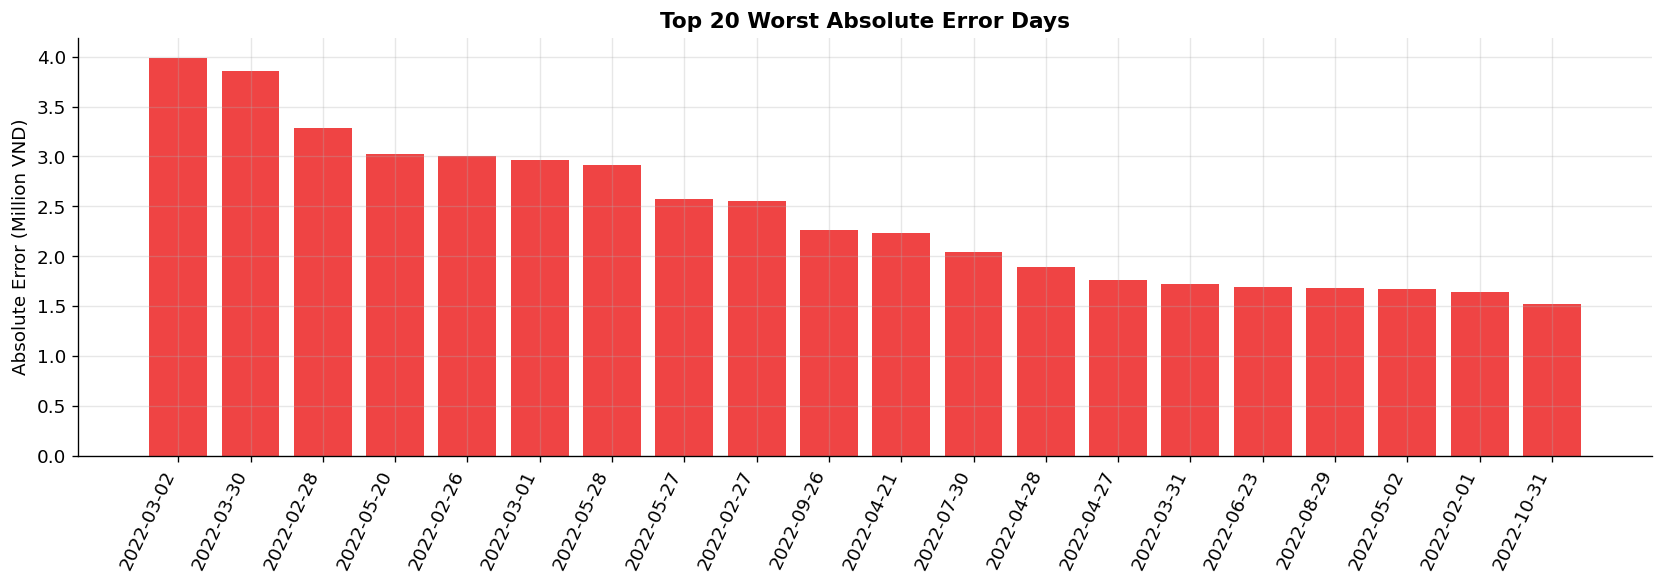

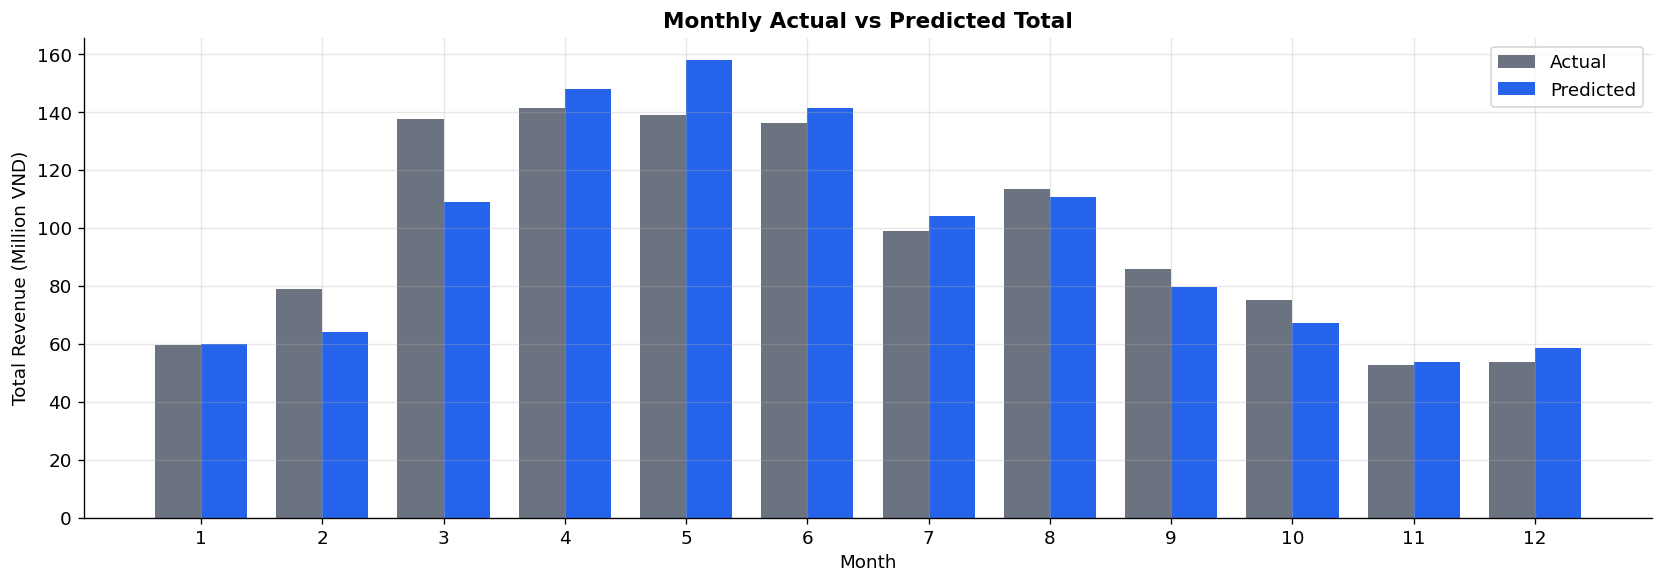

,month,Actual_Total,Predicted_Total,Total_Gap
2,3,1.375379e+08,1.088225e+08,2.871545e+07
4,5,1.390279e+08,1.578259e+08,-1.879802e+07
1,2,7.910310e+07,6.420396e+07,1.489914e+07
9,10,7.519445e+07,6.714654e+07,8.047909e+06
3,4,1.413055e+08,1.479218e+08,-6.616261e+06
8,9,8.576429e+07,7.950224e+07,6.262044e+06
5,6,1.361281e+08,1.415573e+08,-5.429204e+06
6,7,9.890855e+07,1.042960e+08,-5.387454e+06
11,12,5.364906e+07,5.850445e+07,-4.855394e+06
7,8,1.135429e+08,1.106183e+08,2.924655e+06


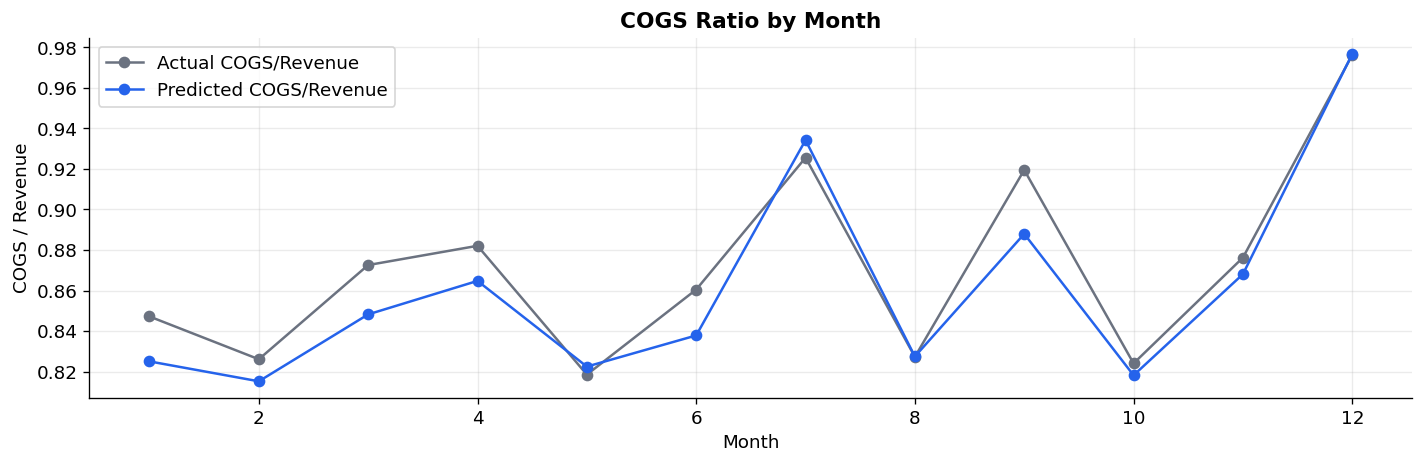

,month,actual_cogs_ratio,pred_cogs_ratio,COGS_MAE
2,3,0.872575,0.848217,944478.049153
4,5,0.818489,0.822446,783233.107986
3,4,0.882071,0.864747,696083.205417
1,2,0.826064,0.815183,646965.632621
7,8,0.827254,0.827429,538721.060422
8,9,0.919521,0.887966,519889.831055
6,7,0.925584,0.934239,474857.848111
5,6,0.860467,0.837825,417002.264138
9,10,0.824021,0.818144,380615.542010
0,1,0.847180,0.825006,373325.340721


,feature,importance
0,lag_1,13.120988
1,lag_365,8.628125
2,lag_364,4.897578
3,rev_vs_ma30,3.022866
4,day,2.952196
5,elapsed_days,2.247622
6,days_to_month_end,2.199958
7,lag_28,2.022352
8,lag_14,1.954739
9,lag_7,1.947629


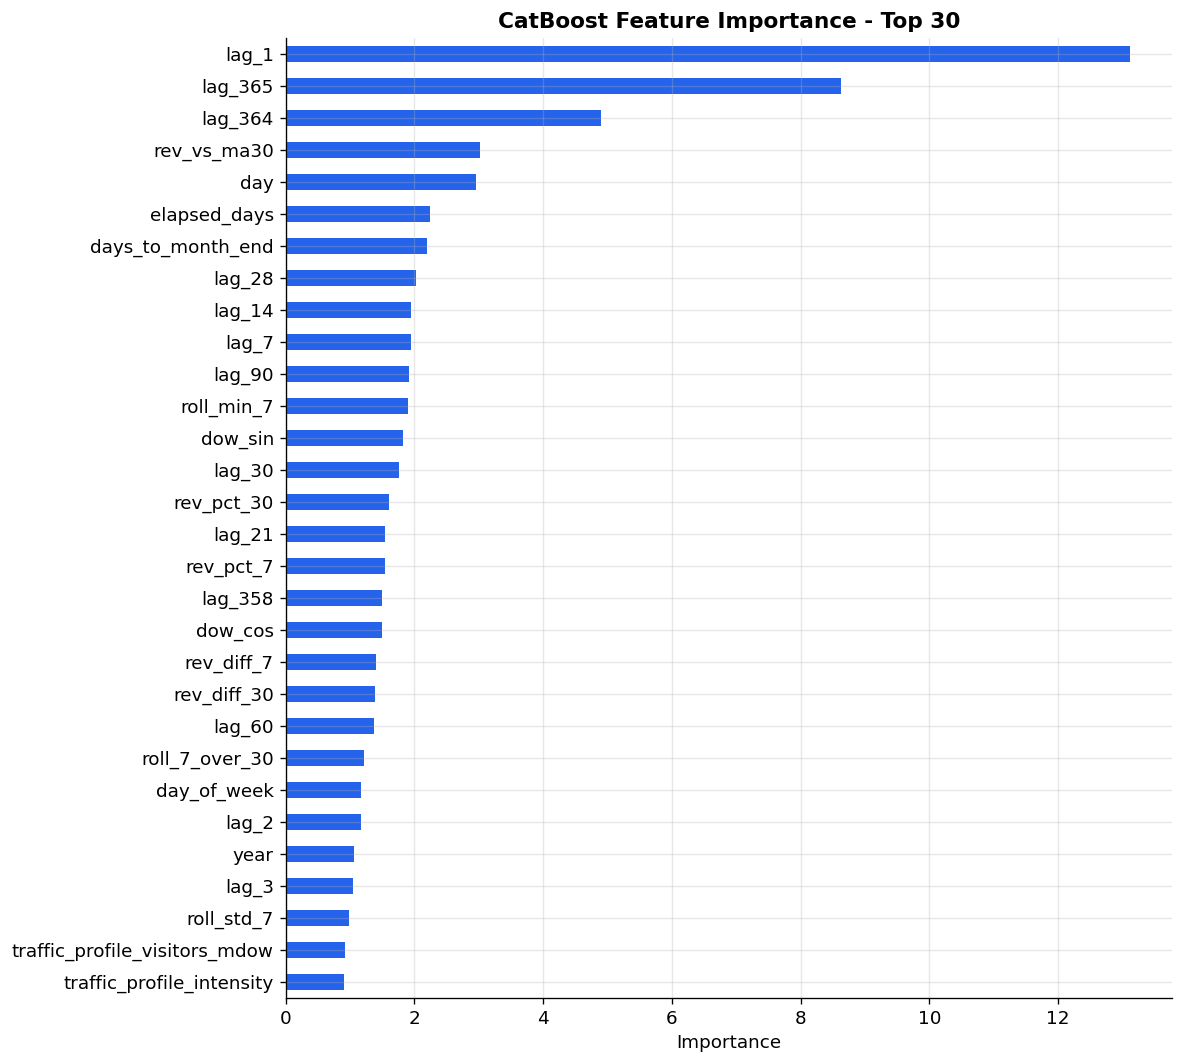

In [21]:
from IPython.display import display
from feature_engineering import add_time_features, add_vn_calendar

diag_df = pd.DataFrame({
    "Date": pd.to_datetime(valid_df["Date"]),
    "Actual": valid_df["Revenue"].to_numpy(dtype=float),
    "Predicted": np.asarray(selected_val_pred_final, dtype=float),
})
diag_df["Residual"] = diag_df["Actual"] - diag_df["Predicted"]
diag_df["AbsError"] = diag_df["Residual"].abs()
diag_df["APE"] = diag_df["AbsError"] / diag_df["Actual"].replace(0, np.nan)
diag_df = add_time_features(diag_df, "Date")
diag_df = add_vn_calendar(diag_df, "Date")
diag_df["weekday_name"] = diag_df["Date"].dt.day_name()

def _event_bucket(row):
    if row.get("is_tet", 0) == 1:
        return "tet"
    if row.get("is_pre_tet", 0) == 1:
        return "pre_tet"
    if row.get("is_post_tet", 0) == 1:
        return "post_tet"
    if row.get("is_sale_event", 0) == 1:
        return "sale_event_day"
    if row.get("is_pre_sale_event", 0) == 1:
        return "pre_sale_event"
    if row.get("is_post_sale_event", 0) == 1:
        return "post_sale_event"
    if row.get("is_q1_end_spike", 0) == 1:
        return "q1_end_spike"
    if row.get("is_aug_end_spike", 0) == 1:
        return "aug_end_spike"
    if row.get("is_back2school_extended", 0) == 1:
        return "back2school_extended"
    return "normal"

diag_df["event_bucket"] = diag_df.apply(_event_bucket, axis=1)

valid_metrics = compute_metrics(diag_df["Actual"].to_numpy(), diag_df["Predicted"].to_numpy())
print("Validation diagnostics metrics:")
print(f"  MAE={valid_metrics['MAE']:,.0f}  RMSE={valid_metrics['RMSE']:,.0f}  R2={valid_metrics['R2']:.3f}")
print(f"  Mean residual={diag_df['Residual'].mean():,.0f}  Median residual={diag_df['Residual'].median():,.0f}")

# 1. Actual vs Predicted + residual over time
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(diag_df["Date"], diag_df["Actual"] / 1e6, label="Actual", color="#6B7280", linewidth=1.4)
axes[0].plot(diag_df["Date"], diag_df["Predicted"] / 1e6, label="Predicted", color="#2563EB", linestyle="--", linewidth=1.4)
axes[0].set_title(f"Final Validation 2022 - {FINAL_REVENUE_CANDIDATE_NAME}")
axes[0].set_ylabel("Revenue (Million VND)")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].bar(diag_df["Date"], diag_df["Residual"] / 1e6, color="#FDBA74", width=1.0)
axes[1].axhline(0, color="black", linewidth=0.9)
axes[1].set_ylabel("Residual (Million VND)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2. Residual by month
month_summary = diag_df.groupby("month").agg(
    Mean_Residual=("Residual", "mean"),
    MAE=("AbsError", "mean"),
    RMSE=("Residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
    Actual_Mean=("Actual", "mean"),
    Pred_Mean=("Predicted", "mean"),
    Days=("Date", "count"),
).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(month_summary["month"], month_summary["Mean_Residual"] / 1e6, color="#60A5FA")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean Residual by Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Million VND")
axes[1].bar(month_summary["month"], month_summary["MAE"] / 1e6, color="#F97316")
axes[1].set_title("MAE by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Million VND")
plt.tight_layout()
plt.show()
display(month_summary.sort_values("MAE", ascending=False))

# 3. Residual by day of week
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_summary = diag_df.groupby("weekday_name").agg(
    Mean_Residual=("Residual", "mean"),
    MAE=("AbsError", "mean"),
    Days=("Date", "count"),
).reindex(weekday_order).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(weekday_summary["weekday_name"], weekday_summary["Mean_Residual"] / 1e6, color="#22C55E")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean Residual by Day of Week")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(weekday_summary["weekday_name"], weekday_summary["MAE"] / 1e6, color="#A855F7")
axes[1].set_title("MAE by Day of Week")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()
display(weekday_summary.sort_values("MAE", ascending=False))

# 4. Residual by event window
event_summary = diag_df.groupby("event_bucket").agg(
    Mean_Residual=("Residual", "mean"),
    MAE=("AbsError", "mean"),
    RMSE=("Residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
    Actual_Mean=("Actual", "mean"),
    Pred_Mean=("Predicted", "mean"),
    Days=("Date", "count"),
).reset_index().sort_values("MAE", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(event_summary["event_bucket"], event_summary["Mean_Residual"] / 1e6, color="#0EA5E9")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean Residual by Event Window")
axes[0].tick_params(axis="x", rotation=35)
axes[1].bar(event_summary["event_bucket"], event_summary["MAE"] / 1e6, color="#EF4444")
axes[1].set_title("MAE by Event Window")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()
display(event_summary)

# 5. Scatter actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(diag_df["Actual"] / 1e6, diag_df["Predicted"] / 1e6, alpha=0.65, color="#2563EB")
max_val = max(diag_df["Actual"].max(), diag_df["Predicted"].max()) / 1e6
plt.plot([0, max_val], [0, max_val], color="black", linestyle="--", linewidth=1)
plt.title("Actual vs Predicted Scatter")
plt.xlabel("Actual Revenue (Million VND)")
plt.ylabel("Predicted Revenue (Million VND)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 6. Error distribution histogram
plt.figure(figsize=(10, 4))
plt.hist(diag_df["Residual"] / 1e6, bins=40, color="#FDBA74", edgecolor="white")
plt.axvline(0, color="black", linewidth=1)
plt.axvline(diag_df["Residual"].mean() / 1e6, color="#2563EB", linestyle="--", label="Mean residual")
plt.title("Residual Distribution")
plt.xlabel("Residual: Actual - Predicted (Million VND)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Top 20 worst error days
event_cols = [
    "is_pre_tet", "is_tet", "is_post_tet", "is_sale_event", "is_pre_sale_event", "is_post_sale_event",
    "is_1111", "is_1212", "is_black_friday", "is_back2school", "is_back2school_extended",
    "is_month_end_window", "is_quarter_end_window", "is_q1_end_spike", "is_aug_end_spike", "is_year_end",
]
top_error_cols = ["Date", "Actual", "Predicted", "Residual", "AbsError", "month", "weekday_name", "event_bucket"] + [c for c in event_cols if c in diag_df.columns]
top_errors = diag_df.sort_values("AbsError", ascending=False).head(20)[top_error_cols].copy()
display(top_errors)
plt.figure(figsize=(14, 5))
plt.bar(top_errors["Date"].dt.strftime("%Y-%m-%d"), top_errors["AbsError"] / 1e6, color="#EF4444")
plt.title("Top 20 Worst Absolute Error Days")
plt.ylabel("Absolute Error (Million VND)")
plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()

# 8. Monthly actual vs predicted total
monthly_total = diag_df.groupby("month").agg(
    Actual_Total=("Actual", "sum"),
    Predicted_Total=("Predicted", "sum"),
).reset_index()
monthly_total["Total_Gap"] = monthly_total["Actual_Total"] - monthly_total["Predicted_Total"]
x = np.arange(len(monthly_total))
width = 0.38
plt.figure(figsize=(14, 5))
plt.bar(x - width / 2, monthly_total["Actual_Total"] / 1e6, width=width, label="Actual", color="#6B7280")
plt.bar(x + width / 2, monthly_total["Predicted_Total"] / 1e6, width=width, label="Predicted", color="#2563EB")
plt.xticks(x, monthly_total["month"])
plt.title("Monthly Actual vs Predicted Total")
plt.xlabel("Month")
plt.ylabel("Total Revenue (Million VND)")
plt.legend()
plt.tight_layout()
plt.show()
display(monthly_total.sort_values("Total_Gap", key=lambda s: s.abs(), ascending=False))

# 9. COGS ratio actual vs predicted by month
cogs_monthly_valid_diag = predict_cogs(selected_val_pred_final, valid_df["Date"], train_df)
cogs_ratio_model_valid_diag, _ = forecast_cogs_ratio_model(
    train_df,
    selected_val_pred_final,
    valid_df["Date"],
    best_promo_profile,
    traffic_profile=best_traffic_profile,
    inventory_profile=best_inventory_profile,
    business_daily=best_business_daily,
    business_profile=best_business_profile,
    business_groups=best_business_groups,
)
cogs_pred_valid_diag = (1.0 - COGS_RATIO_MODEL_WEIGHT) * cogs_monthly_valid_diag + COGS_RATIO_MODEL_WEIGHT * cogs_ratio_model_valid_diag
cogs_pred_valid_diag = np.minimum(np.maximum(cogs_pred_valid_diag, 0), np.maximum(selected_val_pred_final, 0) * 0.995)
cogs_diag = valid_df[["Date", "Revenue", "COGS"]].copy()
cogs_diag["Predicted_Revenue"] = selected_val_pred_final
cogs_diag["Predicted_COGS"] = cogs_pred_valid_diag
cogs_diag["actual_cogs_ratio"] = cogs_diag["COGS"] / cogs_diag["Revenue"].replace(0, np.nan)
cogs_diag["pred_cogs_ratio"] = cogs_diag["Predicted_COGS"] / cogs_diag["Predicted_Revenue"].replace(0, np.nan)
cogs_diag["month"] = pd.to_datetime(cogs_diag["Date"]).dt.month
cogs_ratio_monthly = cogs_diag.groupby("month").agg(
    actual_cogs_ratio=("actual_cogs_ratio", "mean"),
    pred_cogs_ratio=("pred_cogs_ratio", "mean"),
    COGS_MAE=("COGS", lambda s: np.nan),
).reset_index()
cogs_ratio_monthly["COGS_MAE"] = cogs_diag.groupby("month").apply(lambda g: np.mean(np.abs(g["COGS"] - g["Predicted_COGS"]))).values
plt.figure(figsize=(12, 4))
plt.plot(cogs_ratio_monthly["month"], cogs_ratio_monthly["actual_cogs_ratio"], marker="o", label="Actual COGS/Revenue", color="#6B7280")
plt.plot(cogs_ratio_monthly["month"], cogs_ratio_monthly["pred_cogs_ratio"], marker="o", label="Predicted COGS/Revenue", color="#2563EB")
plt.title("COGS Ratio by Month")
plt.xlabel("Month")
plt.ylabel("COGS / Revenue")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(cogs_ratio_monthly.sort_values("COGS_MAE", ascending=False))

# 10. CatBoost feature importance
cat_importance_model = best_art.get("cat_model") if "best_art" in globals() else None
cat_importance_cols = best_art.get("feat_cols") if "best_art" in globals() else None
if cat_importance_model is None and "final_cat" in globals() and final_cat is not None:
    cat_importance_model = final_cat
    cat_importance_cols = feat_cols_full

if cat_importance_model is not None and hasattr(cat_importance_model, "get_feature_importance"):
    cat_fi = pd.Series(cat_importance_model.get_feature_importance(), index=cat_importance_cols).sort_values(ascending=False)
    display(cat_fi.head(40).rename("importance").reset_index().rename(columns={"index": "feature"}))
    plt.figure(figsize=(10, 9))
    cat_fi.head(30).sort_values().plot(kind="barh", color="#2563EB")
    plt.title("CatBoost Feature Importance - Top 30")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("CatBoost feature importance skipped: CatBoost model is not available.")



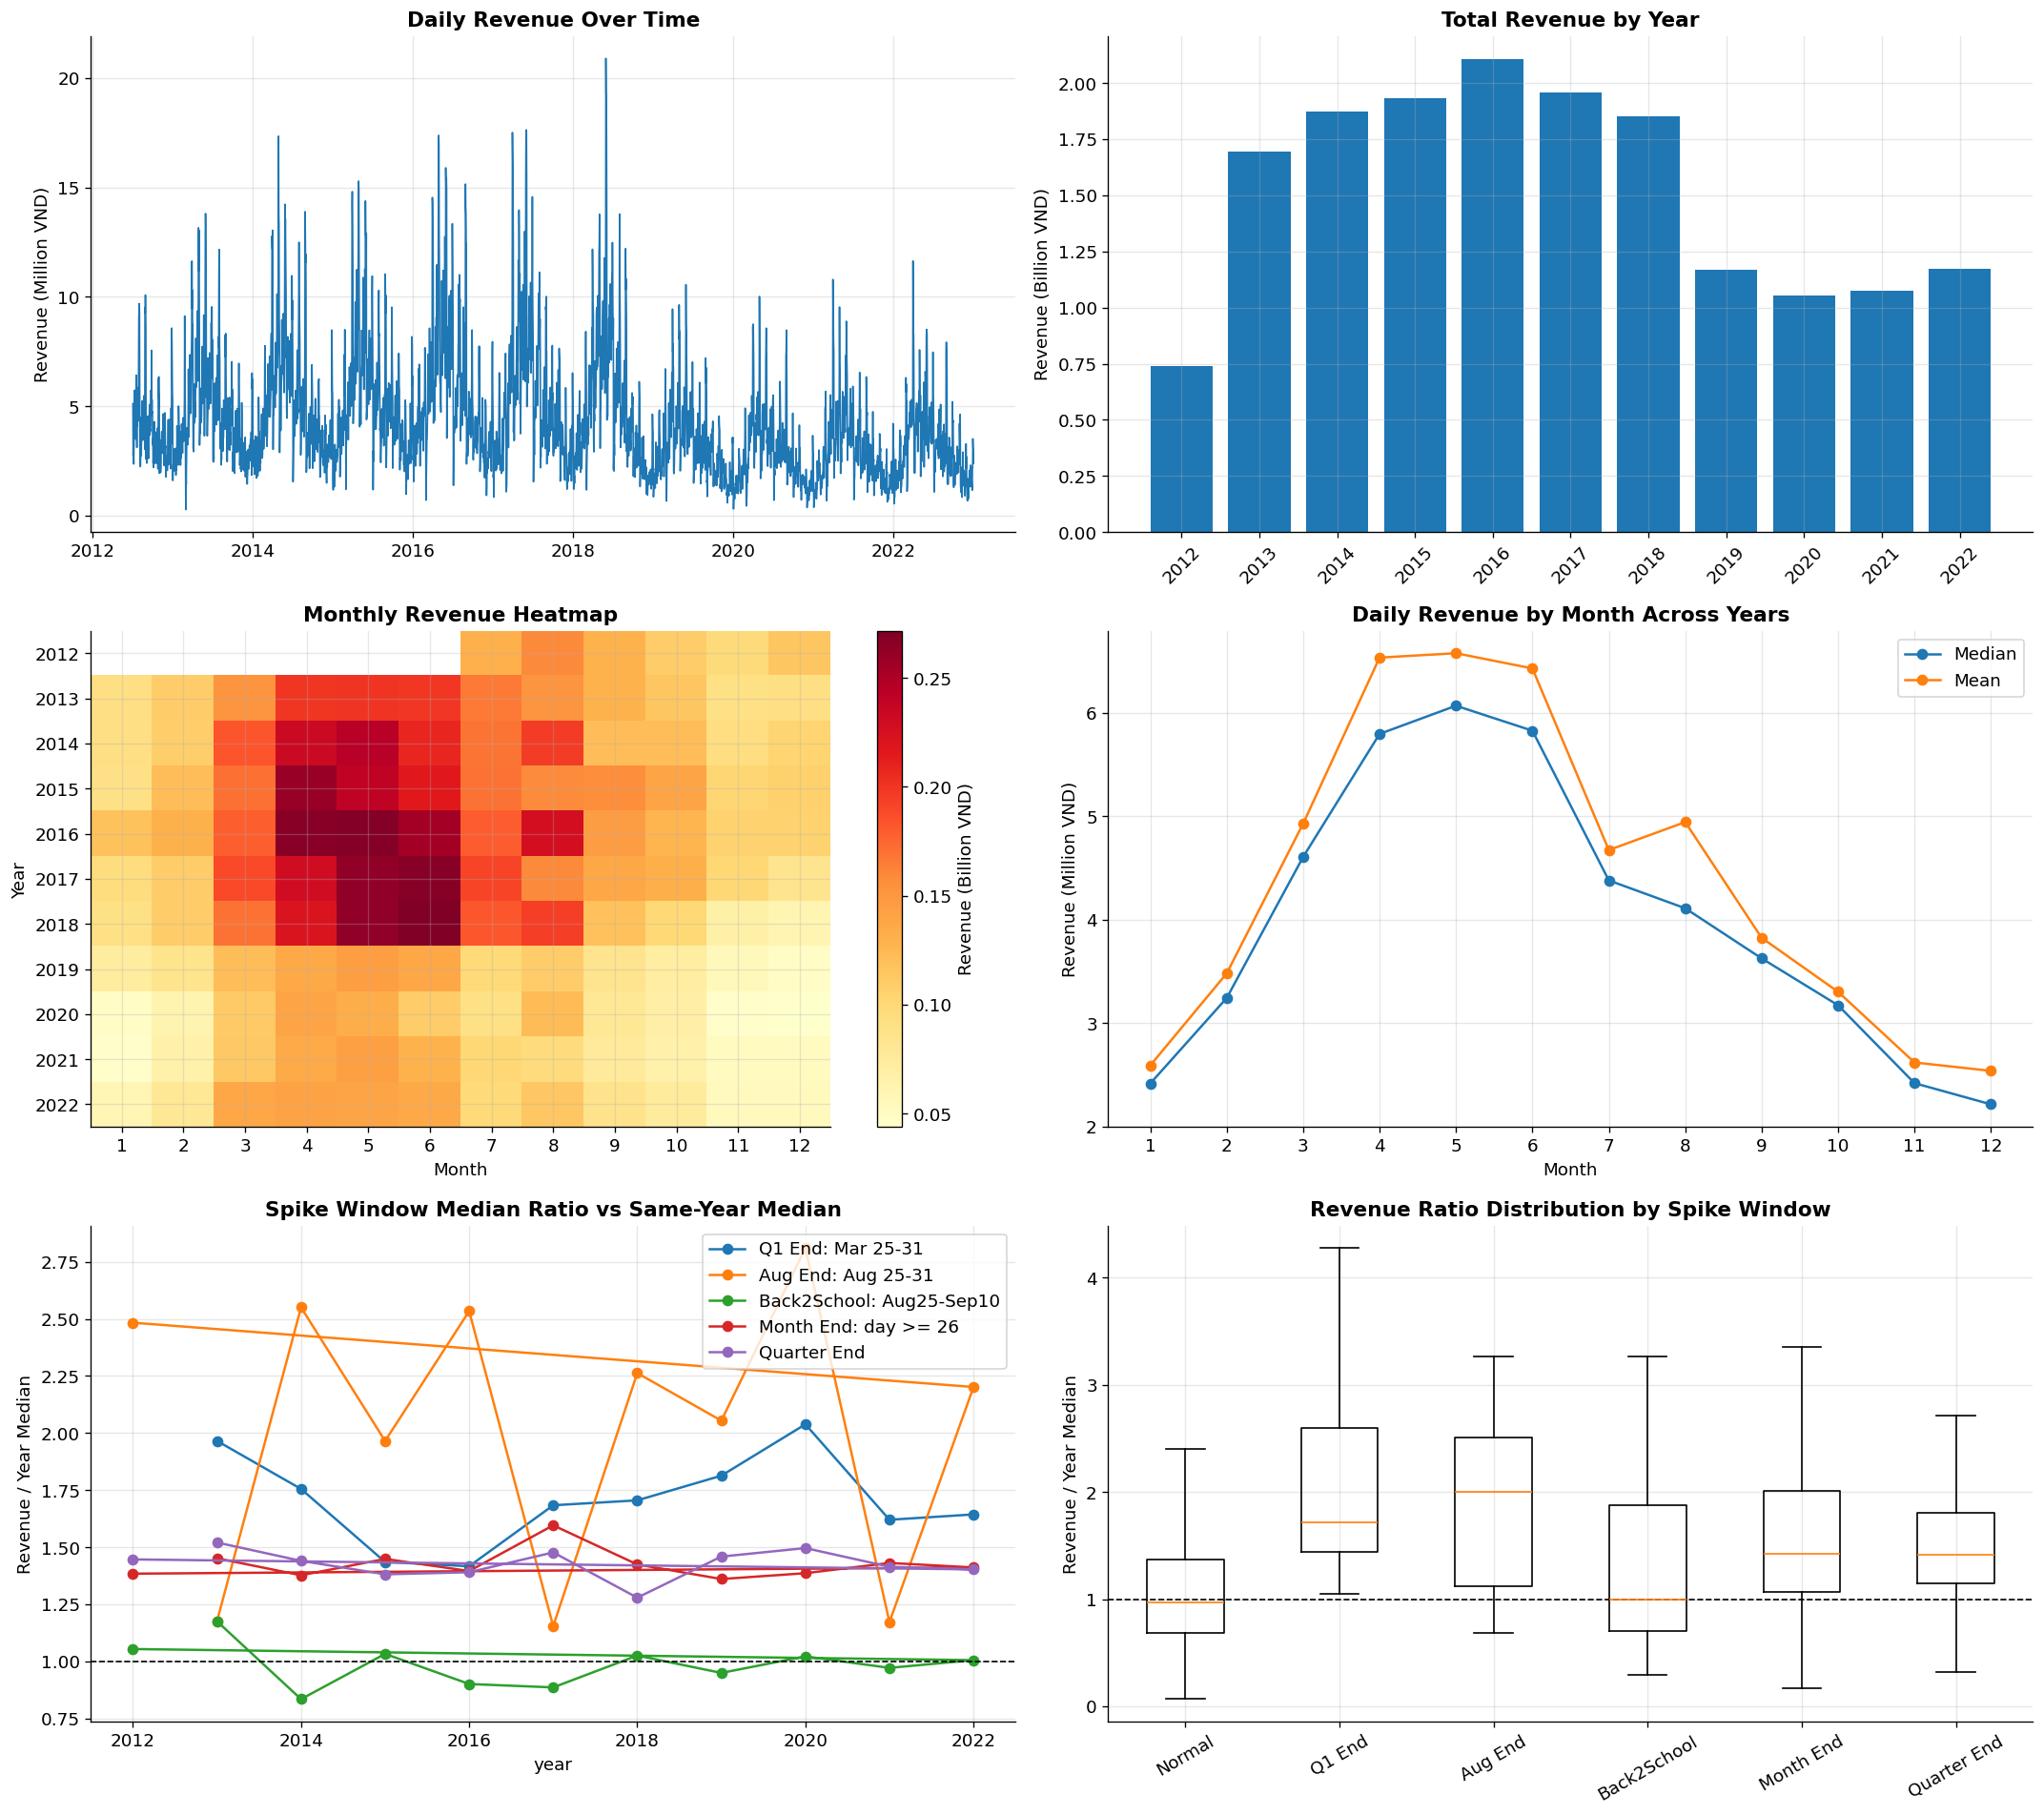

Spike Window Summary


,window,days,median_revenue,normal_median_revenue,median_ratio_vs_normal,median_ratio_vs_year,mean_ratio_vs_year
0,Q1 End: Mar 25-31,70,6726864.530,3657388.710,1.839253,1.718283,2.017907
1,Aug End: Aug 25-31,77,6368386.980,3663913.970,1.738138,2.002857,1.825961
2,Back2School: Aug25-Sep10,187,3741666.750,3686161.205,1.015058,1.000371,1.291930
3,Month End: day >= 26,686,5428735.405,3461580.000,1.568283,1.425240,1.602083
4,Quarter End,273,5371586.260,3612181.775,1.487075,1.416928,1.532217



Year-by-year spike ratios:


,Q1 End: Mar 25-31,Aug End: Aug 25-31,Back2School: Aug25-Sep10,Month End: day >= 26,Quarter End
year,,,,,
2013,1.966,1.176,1.176,1.452,1.521
2014,1.755,2.550,0.835,1.377,1.440
2015,1.436,1.966,1.033,1.449,1.382
2016,1.417,2.534,0.901,1.396,1.391
2017,1.684,1.155,0.886,1.596,1.478
2018,1.705,2.263,1.026,1.425,1.279
2019,1.813,2.054,0.950,1.361,1.459
2020,2.038,2.810,1.022,1.386,1.496
2021,1.620,1.172,0.972,1.431,1.415


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

viz_sales = sales.copy()
viz_sales["Date"] = pd.to_datetime(viz_sales["Date"])
viz_sales = viz_sales.sort_values("Date").reset_index(drop=True)

viz_sales["year"] = viz_sales["Date"].dt.year
viz_sales["month"] = viz_sales["Date"].dt.month
viz_sales["day"] = viz_sales["Date"].dt.day
viz_sales["weekday"] = viz_sales["Date"].dt.day_name()

viz_sales["is_q1_end_spike"] = ((viz_sales["month"] == 3) & (viz_sales["day"] >= 25)).astype(int)
viz_sales["is_aug_end_spike"] = ((viz_sales["month"] == 8) & (viz_sales["day"] >= 25)).astype(int)
viz_sales["is_back2school_extended"] = (
    ((viz_sales["month"] == 8) & (viz_sales["day"] >= 25)) |
    ((viz_sales["month"] == 9) & (viz_sales["day"] <= 10))
).astype(int)
viz_sales["is_month_end_window"] = (viz_sales["day"] >= 26).astype(int)
viz_sales["is_quarter_end_window"] = (
    viz_sales["month"].isin([3, 6, 9, 12]) & (viz_sales["day"] >= 25)
).astype(int)

# Daily baseline cùng năm để tính ratio spike / normal
year_median = viz_sales.groupby("year")["Revenue"].transform("median")
viz_sales["revenue_vs_year_median"] = viz_sales["Revenue"] / year_median.replace(0, np.nan)

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.ravel()

# 1. Revenue daily theo thời gian
axes[0].plot(viz_sales["Date"], viz_sales["Revenue"] / 1e6, linewidth=1)
axes[0].set_title("Daily Revenue Over Time")
axes[0].set_ylabel("Revenue (Million VND)")
axes[0].grid(alpha=0.3)

# 2. Tổng revenue theo năm
yearly = viz_sales.groupby("year")["Revenue"].sum() / 1e9
axes[1].bar(yearly.index.astype(str), yearly.values)
axes[1].set_title("Total Revenue by Year")
axes[1].set_ylabel("Revenue (Billion VND)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

# 3. Monthly total heatmap year x month
monthly = (
    viz_sales
    .groupby(["year", "month"])["Revenue"]
    .sum()
    .unstack("month")
    / 1e9
)
im = axes[2].imshow(monthly.values, aspect="auto", cmap="YlOrRd")
axes[2].set_title("Monthly Revenue Heatmap")
axes[2].set_yticks(range(len(monthly.index)))
axes[2].set_yticklabels(monthly.index)
axes[2].set_xticks(range(12))
axes[2].set_xticklabels(range(1, 13))
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Year")
fig.colorbar(im, ax=axes[2], label="Revenue (Billion VND)")

# 4. Median daily revenue by month across years
month_stats = (
    viz_sales
    .groupby("month")["Revenue"]
    .agg(["median", "mean"])
    / 1e6
)
axes[3].plot(month_stats.index, month_stats["median"], marker="o", label="Median")
axes[3].plot(month_stats.index, month_stats["mean"], marker="o", label="Mean")
axes[3].set_title("Daily Revenue by Month Across Years")
axes[3].set_xlabel("Month")
axes[3].set_ylabel("Revenue (Million VND)")
axes[3].set_xticks(range(1, 13))
axes[3].legend()
axes[3].grid(alpha=0.3)

# 5. Spike window ratio by year
spike_rows = []
for name, col in [
    ("Q1 End: Mar 25-31", "is_q1_end_spike"),
    ("Aug End: Aug 25-31", "is_aug_end_spike"),
    ("Back2School: Aug25-Sep10", "is_back2school_extended"),
    ("Month End: day >= 26", "is_month_end_window"),
    ("Quarter End", "is_quarter_end_window"),
]:
    tmp = (
        viz_sales[viz_sales[col] == 1]
        .groupby("year")["revenue_vs_year_median"]
        .median()
        .rename(name)
    )
    spike_rows.append(tmp)

spike_ratio = pd.concat(spike_rows, axis=1)
spike_ratio.plot(ax=axes[4], marker="o")
axes[4].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[4].set_title("Spike Window Median Ratio vs Same-Year Median")
axes[4].set_ylabel("Revenue / Year Median")
axes[4].grid(alpha=0.3)

# 6. Boxplot ratio by window
box_data = []
box_labels = []
for name, col in [
    ("Normal", None),
    ("Q1 End", "is_q1_end_spike"),
    ("Aug End", "is_aug_end_spike"),
    ("Back2School", "is_back2school_extended"),
    ("Month End", "is_month_end_window"),
    ("Quarter End", "is_quarter_end_window"),
]:
    if col is None:
        mask = (
            (viz_sales["is_q1_end_spike"] == 0) &
            (viz_sales["is_aug_end_spike"] == 0) &
            (viz_sales["is_back2school_extended"] == 0) &
            (viz_sales["is_quarter_end_window"] == 0)
        )
    else:
        mask = viz_sales[col] == 1

    box_data.append(viz_sales.loc[mask, "revenue_vs_year_median"].dropna().clip(0, 5))
    box_labels.append(name)

axes[5].boxplot(box_data, labels=box_labels, showfliers=False)
axes[5].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[5].set_title("Revenue Ratio Distribution by Spike Window")
axes[5].set_ylabel("Revenue / Year Median")
axes[5].tick_params(axis="x", rotation=30)
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 100)
print("Spike Window Summary")
print("=" * 100)

summary_rows = []
for name, col in [
    ("Q1 End: Mar 25-31", "is_q1_end_spike"),
    ("Aug End: Aug 25-31", "is_aug_end_spike"),
    ("Back2School: Aug25-Sep10", "is_back2school_extended"),
    ("Month End: day >= 26", "is_month_end_window"),
    ("Quarter End", "is_quarter_end_window"),
]:
    grp = viz_sales[viz_sales[col] == 1]
    normal = viz_sales[viz_sales[col] == 0]

    summary_rows.append({
        "window": name,
        "days": len(grp),
        "median_revenue": grp["Revenue"].median(),
        "normal_median_revenue": normal["Revenue"].median(),
        "median_ratio_vs_normal": grp["Revenue"].median() / normal["Revenue"].median(),
        "median_ratio_vs_year": grp["revenue_vs_year_median"].median(),
        "mean_ratio_vs_year": grp["revenue_vs_year_median"].mean(),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("\nYear-by-year spike ratios:")
display(spike_ratio.round(3))
